# F5 Pro System — v5

| | |
|---|---|
| Version | v5 |
| Target | First 5 Innings moneyline (home_wins_f5) |
| Walk-forward AUC | TBD (retrain required) |

### Changes from v4
- **New Statcast pitcher features** — `avg_velo_L5`, `avg_pfxz_L5`, `avg_spin_L5`, `fb_pct_L5`, `breaking_pct_L5`
- **New Statcast batter features** — `bat_speed_L20`, `swing_length_L20`, `bat_speed_has_data` (missingness flag, 2023+ only)
- **Inference fix** — Section 13a prediction always builds full feature vector from `model['features']`; missing weather/ump features filled with training-time mean and pick flagged with `[DATA?]`
- **Statcast master** now reads from `statcast_master.csv` directly (single file, no daily cache rebuild needed)
- **Version bumps** — config, model file, meta file, bet DB all incremented to v5

### Run order
```
0a → 0b → 0c → 0d
statcast_rebuild_master_f5(cfg)   # ~1 min (reads master CSV, filters inn 1-5)
rebuild_joins_only(cfg)           # ~2 min
build_nrfi_features(cfg)          # ~30s
run_feature_diagnostics()         # verify coverage
run_optuna_search(n_trials=100)   # optional ~20 min
train_f5_model(cfg)
walk_forward_validation()
run_rigor_assessment()
train_f5_model_full(cfg)          # production model
```

## Section 0a: Install & Imports

In [32]:
import subprocess, sys
pkgs = ["pandas","numpy","scikit-learn","xgboost","requests",
        "tqdm","seaborn","matplotlib","pytz","shap","scipy","optuna"]
r = subprocess.run([sys.executable,"-m","pip","install","--quiet"]+pkgs,
                   capture_output=True, text=True)
print("✅ Packages ready" if r.returncode==0 else f"⚠️  {r.stderr[-300:]}")

✅ Packages ready


In [33]:
import os, sys, json, time, random, sqlite3, warnings
from datetime import datetime, date, timedelta
from pathlib import Path
from io import StringIO

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pytz
import pytz as _tz
import shap
from scipy import stats as _stats
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
try:
    from tqdm.notebook import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

print(f"✅ Imports loaded — {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports loaded — 2026-04-03 12:33


## Section 0b: Config

In [34]:
BASE_DIR  = r"C:\Users\lmayn\Downloads\F5_Pro_System"
NRFI_DIR  = r"C:\Users\lmayn\Downloads\NRFI_Pro_System_Complete.tar_4\NRFI_Pro_System"
HR_DIR    = r"C:\Users\lmayn\Downloads\HR_Pro"

cfg = {
    "version":      "v5",
    "base_dir":     BASE_DIR,
    "season_start":       2021,
    "season_start_month": 3,
    "season_end_month":   10,
    "mlb_season_ranges": {
        2021: ("2021-04-01","2021-10-03"), 2022: ("2022-04-07","2022-10-05"),
        2023: ("2023-03-30","2023-10-01"), 2024: ("2024-03-20","2024-09-29"),
        2025: ("2025-03-18","2025-09-28"), 2026: ("2026-03-26","2026-10-04"),
    },
    # v5: reads from single statcast_master.csv directly
    "statcast_master_src": r"C:\Users\lmayn\Downloads\Baseball_Data\Statcast\statcast_master.csv",
    "statcast_master":    os.path.join(BASE_DIR, "statcast_f5_master.csv"),
    "weather_master":     os.path.join(HR_DIR, "weather_master.csv"),
    "umpire_master":      os.path.join(NRFI_DIR, "cache_umps"),
    "nrfi_lineups":       os.path.join(NRFI_DIR, "lineups_master.csv"),
    "nrfi_pitcher_feats": os.path.join(NRFI_DIR, "pitcher_start_features.csv"),
    "hr_game_features":   os.path.join(HR_DIR, "game_features_master.csv"),
    "odds_master":        os.path.join(BASE_DIR, "f5_odds_master.csv"),
    "game_features":      os.path.join(BASE_DIR, "f5_game_features.csv"),
    "model_f5":           os.path.join(BASE_DIR, "models", "xgb_f5_v5.json"),
    "model_meta":         os.path.join(BASE_DIR, "models", "model_meta_f5_v5.json"),
    "feature_means":      os.path.join(BASE_DIR, "models", "feature_means_f5_v5.json"),
    "bet_db":             os.path.join(BASE_DIR, "data", "f5_bets_v5.db"),
    "min_edge":       0.04,  "kelly_fraction": 0.25,
    "min_kelly_pct":  0.005, "max_kelly_pct":  0.05,
    "paper_mode":     True,  "bankroll":       1000,
}

SEASON_WEIGHTS = {2021:0.25, 2022:0.5, 2023:0.75, 2024:1.0, 2025:1.0, 2026:1.0}

for d in ["models","data"]:
    Path(os.path.join(BASE_DIR,d)).mkdir(parents=True,exist_ok=True)

data = {}; features = None; model = {}; tracker = None

print(f"✅ Config v5 | NRFI_DIR exists: {os.path.exists(NRFI_DIR)}")
print(f"   statcast_master_src: {os.path.exists(cfg['statcast_master_src'])}")
print(f"   nrfi_lineups: {os.path.exists(cfg['nrfi_lineups'])}")
print(f"   nrfi_pitcher_feats: {os.path.exists(cfg['nrfi_pitcher_feats'])}")
print(f"   hr_game_features: {os.path.exists(cfg['hr_game_features'])}")

✅ Config v5 | NRFI_DIR exists: True
   statcast_master_src: True
   nrfi_lineups: True
   nrfi_pitcher_feats: True
   hr_game_features: True


## Section 0c: Utilities & Maps

In [35]:
# ── Math ──────────────────────────────────────────────────────────────────
def american_to_implied_prob(odds):
    if pd.isna(odds): return np.nan
    odds = float(odds)
    return 100/(odds+100) if odds > 0 else abs(odds)/(abs(odds)+100)

def remove_vig(prob_a, prob_b):
    total = prob_a + prob_b
    if total <= 0 or pd.isna(total): return np.nan, np.nan
    return prob_a/total, prob_b/total

def kelly_stake(edge, odds, fraction=0.25):
    if pd.isna(edge) or pd.isna(odds) or edge <= 0: return 0
    b = odds/100 if odds > 0 else 100/abs(odds)
    return max(0, (edge/b)*fraction)

def safe_rate(num, denom, default=np.nan):
    if pd.isna(denom) or denom == 0: return default
    return num/denom

def build_date_list(start_date, end_date=None):
    if end_date is None: end_date = date.today()
    if isinstance(start_date, str): start_date = datetime.strptime(start_date,"%Y-%m-%d").date()
    if isinstance(end_date,   str): end_date   = datetime.strptime(end_date,  "%Y-%m-%d").date()
    dates, cursor = [], start_date
    while cursor <= end_date:
        if cfg['season_start_month'] <= cursor.month <= cfg['season_end_month']:
            dates.append(cursor)
        cursor += timedelta(days=1)
    return dates

# ── Team maps ─────────────────────────────────────────────────────────────
TEAM_NAME_TO_ABBREV = {
    "Arizona Diamondbacks":"ARI","Atlanta Braves":"ATL",
    "Baltimore Orioles":"BAL",  "Boston Red Sox":"BOS",
    "Chicago Cubs":"CHC",       "Chicago White Sox":"CWS",
    "Cincinnati Reds":"CIN",    "Cleveland Guardians":"CLE",
    "Cleveland Indians":"CLE",  "Colorado Rockies":"COL",
    "Detroit Tigers":"DET",     "Houston Astros":"HOU",
    "Kansas City Royals":"KC",  "Los Angeles Angels":"LAA",
    "Los Angeles Dodgers":"LAD","Miami Marlins":"MIA",
    "Milwaukee Brewers":"MIL",  "Minnesota Twins":"MIN",
    "New York Mets":"NYM",      "New York Yankees":"NYY",
    "Oakland Athletics":"OAK",  "Athletics":"OAK",
    "Philadelphia Phillies":"PHI","Pittsburgh Pirates":"PIT",
    "San Diego Padres":"SD",    "San Francisco Giants":"SF",
    "Seattle Mariners":"SEA",   "St. Louis Cardinals":"STL",
    "Tampa Bay Rays":"TB",      "Texas Rangers":"TEX",
    "Toronto Blue Jays":"TOR",  "Washington Nationals":"WSH",
}

STATCAST_FIX = {"AZ":"ARI","ATH":"OAK"}

DK_NAME_TO_ABBR = {
    "ARI":"ARI","ATL":"ATL","BAL":"BAL","BOS":"BOS",
    "CHC":"CHC","CWS":"CWS","CIN":"CIN","CLE":"CLE",
    "COL":"COL","DET":"DET","HOU":"HOU","KAN":"KC",  "KC":"KC",  "ROY":"KC",  "MIN Twins":"MIN",
    "LAA":"LAA","LAD":"LAD","MIA":"MIA","MIL":"MIL",
    "MIN":"MIN","NYM":"NYM","NYY":"NYY","OAK":"OAK",
    "PHI":"PHI","PIT":"PIT","SD":"SD","SF":"SF",
    "SEA":"SEA","STL":"STL","TB":"TB","TEX":"TEX",
    "TOR":"TOR","WSH":"WSH","WAS":"WSH",
    "Diamondbacks":"ARI","Braves":"ATL","Orioles":"BAL",
    "Red Sox":"BOS","Cubs":"CHC","White Sox":"CWS",
    "Reds":"CIN","Guardians":"CLE","Rockies":"COL",
    "Tigers":"DET","Astros":"HOU","Royals":"KC",
    "Angels":"LAA","Dodgers":"LAD","Marlins":"MIA",
    "Brewers":"MIL","Twins":"MIN","Mets":"NYM",
    "Yankees":"NYY","Athletics":"OAK","A's":"OAK",
    "Phillies":"PHI","Pirates":"PIT","Padres":"SD",
    "Giants":"SF","Mariners":"SEA","Cardinals":"STL",
    "Rays":"TB","Rangers":"TEX","Blue Jays":"TOR",
    "Nationals":"WSH",
}

STADIUMS = {
    "ARI":(33.4453,-112.0667,"retractable",-7),"ATL":(33.8908,-84.4678,"open",-4),
    "BAL":(39.2838,-76.6218,"open",-4),       "BOS":(42.3467,-71.0972,"open",-4),
    "CHC":(41.9484,-87.6553,"open",-5),        "CWS":(41.8299,-87.6338,"open",-5),
    "CIN":(39.0979,-84.5082,"open",-4),        "CLE":(41.4962,-81.6852,"open",-4),
    "COL":(39.7559,-104.9942,"open",-6),       "DET":(42.3390,-83.0485,"open",-4),
    "HOU":(29.7573,-95.3555,"retractable",-5), "KC":(39.0517,-94.4803,"open",-5),
    "LAA":(33.8003,-117.8827,"open",-7),       "LAD":(34.0739,-118.2400,"open",-7),
    "MIA":(25.7781,-80.2197,"retractable",-4), "MIL":(43.0280,-87.9712,"retractable",-5),
    "MIN":(44.9817,-93.2778,"open",-5),        "NYM":(40.7571,-73.8458,"open",-4),
    "NYY":(40.8296,-73.9262,"open",-4),        "OAK":(37.7516,-122.2005,"open",-7),
    "PHI":(39.9061,-75.1665,"open",-4),        "PIT":(40.4469,-80.0057,"open",-4),
    "SD":(32.7076,-117.1570,"open",-7),        "SF":(37.7786,-122.3893,"open",-7),
    "SEA":(47.5914,-122.3325,"retractable",-7),"STL":(38.6226,-90.1928,"open",-5),
    "TB":(27.7683,-82.6534,"dome",-4),         "TEX":(32.7512,-97.0832,"retractable",-5),
    "TOR":(43.6414,-79.3894,"retractable",-4), "WSH":(38.8730,-77.0074,"open",-4),
}

PARK_FACTORS = {
    "ARI":0.98,"ATL":1.02,"BAL":0.98,"BOS":0.99,"CHC":1.02,
    "CWS":1.01,"CIN":1.08,"CLE":0.97,"COL":1.33,"DET":0.98,
    "HOU":0.97,"KC":1.01,"LAA":1.04,"LAD":1.00,"MIA":0.95,
    "MIL":1.02,"MIN":1.02,"NYM":1.02,"NYY":1.03,"OAK":0.96,
    "PHI":1.05,"PIT":0.99,"SD":0.98,"SF":0.97,"SEA":0.97,
    "STL":1.02,"TB":0.97,"TEX":1.03,"TOR":1.05,"WSH":1.02,
}

ALTITUDE_FT = {"COL":5280,"ARI":1082,"ATL":1050}

def _dk_resolve_name(short):
    if not short: return None
    if short in DK_NAME_TO_ABBR: return DK_NAME_TO_ABBR[short]
    for k,v in DK_NAME_TO_ABBR.items():
        if k.lower() in short.lower() or short.lower() in k.lower(): return v
    return f"???({short})"

print("✅ Utilities and maps loaded")

✅ Utilities and maps loaded


## Section 0d: Diagnostic
Run after loading sections 0a-0c to validate state.

In [36]:
print("="*62)
print("  F5 PRO v5 — DIAGNOSTIC")
print("="*62)

checks = []
def chk(name, fn):
    try:
        result = fn()
        status = "✅" if result is not False else "⚠️ "
        checks.append((status, name))
    except Exception as e:
        checks.append(("❌", f"{name}: {e}"))

chk("Config loaded",           lambda: cfg.get("version")=="v5")
chk("Statcast source exists",  lambda: os.path.exists(cfg["statcast_master_src"]))
chk("Statcast master built",   lambda: os.path.exists(cfg["statcast_master"]) or False)
chk("Game features exist",     lambda: os.path.exists(cfg["game_features"]) or False)
chk("Model file exists",       lambda: os.path.exists(cfg["model_f5"]) or False)
chk("Feature means exist",     lambda: os.path.exists(cfg["feature_means"]) or False)
chk("NRFI lineups exist",      lambda: os.path.exists(cfg["nrfi_lineups"]))
chk("NRFI pitcher feats exist",lambda: os.path.exists(cfg["nrfi_pitcher_feats"]))
chk("HR game features exist",  lambda: os.path.exists(cfg["hr_game_features"]))
chk("Weather master exists",   lambda: os.path.exists(cfg["weather_master"]))
chk("Statcast in memory",      lambda: data.get("statcast") is not None)
chk("Features in memory",      lambda: features is not None)
chk("Model in memory",         lambda: "f5" in model)
chk("Feature means in memory", lambda: "feature_means" in model)

for status, name in checks:
    print(f"  {status} {name}")

if features is not None:
    print(f"\n  Features shape: {features.shape}")
    print(f"  Home win rate:  {features['home_wins_f5'].mean():.3f}")
    print(f"  Date range:     {features['game_date'].min()} → {features['game_date'].max()}")

if "f5" in model:
    print(f"\n  Model features: {len(model.get('features',[]))}")
    print(f"  Feature means:  {len(model.get('feature_means',{}))} keys")

  F5 PRO v5 — DIAGNOSTIC
  ✅ Config loaded
  ✅ Statcast source exists
  ✅ Statcast master built
  ✅ Game features exist
  ✅ Model file exists
  ✅ Feature means exist
  ✅ NRFI lineups exist
  ✅ NRFI pitcher feats exist
  ✅ HR game features exist
  ✅ Weather master exists
  ⚠️  Statcast in memory
  ⚠️  Features in memory
  ⚠️  Model in memory
  ⚠️  Feature means in memory


## Section 1: Statcast Master Rebuild
v5: reads directly from `statcast_master.csv` (single file), filters `inning <= 5`, saves to F5 master.  
**Run:** `statcast_rebuild_master_f5(cfg)` — ~1-2 min.

In [37]:
STATCAST_FIELDS = [
    "game_pk","game_date","inning","inning_topbot",
    "pitcher","player_name","batter","stand","p_throws",
    "home_team","away_team","at_bat_number","pitch_type",
    "release_speed","release_spin_rate","pfx_x","pfx_z",
    "events","description",
    "estimated_woba_using_speedangle","woba_value",
    "launch_speed","launch_angle","outs_when_up",
    # v5 new
    "bat_speed","swing_length",
    # optional
    "arm_angle","pitcher_days_since_prev_game",
]

def statcast_rebuild_master_f5(cfg):
    src = cfg["statcast_master_src"]
    if not os.path.exists(src):
        print(f"⚠️  Source not found: {src}"); return
    print(f"Reading {src}...")
    available_cols = list(pd.read_csv(src, nrows=0).columns)
    use_cols = [c for c in STATCAST_FIELDS if c in available_cols]
    master = pd.read_csv(src, usecols=use_cols, low_memory=False)
    master["game_date"] = pd.to_datetime(master["game_date"])
    if "inning" in master.columns:
        master = master[pd.to_numeric(master["inning"],errors="coerce") <= 5]
    # Apply team abbreviation fixes
    for col in ["home_team","away_team"]:
        if col in master.columns:
            master[col] = master[col].replace(STATCAST_FIX)
    before = len(master)
    dedup_cols = [c for c in ["game_pk","pitcher","at_bat_number","outs_when_up"] if c in master.columns]
    master = master.drop_duplicates(subset=dedup_cols)
    master.to_csv(cfg["statcast_master"], index=False)
    data["statcast"] = master
    print(f"  ✅ {before:,} → {len(master):,} rows (inn 1-5)")
    print(f"     {master['game_pk'].nunique():,} unique games | {master['game_date'].min().date()} → {master['game_date'].max().date()}")
    print(f"     bat_speed coverage: {master['bat_speed'].notna().mean():.1%}")
    print(f"     release_speed coverage: {master['release_speed'].notna().mean():.1%}")

if Path(cfg["statcast_master"]).exists():
    data["statcast"] = pd.read_csv(cfg["statcast_master"], low_memory=False)
    data["statcast"]["game_date"] = pd.to_datetime(data["statcast"]["game_date"])
    print(f"✅ Statcast loaded: {len(data['statcast']):,} rows | {data['statcast']['game_pk'].nunique():,} games")
else:
    print("ℹ️  No master — run statcast_rebuild_master_f5(cfg)")

✅ Statcast loaded: 519,550 rows | 12,236 games


## Section 2: Probable Pitcher Pull

In [38]:
def fetch_probable_pitchers(target_date=None):
    target = target_date or date.today().strftime("%Y-%m-%d")
    try:
        resp = requests.get(
            f"https://statsapi.mlb.com/api/v1/schedule"
            f"?sportId=1&date={target}&hydrate=probablePitcher",
            timeout=10
        )
        resp.raise_for_status()
        schedule = resp.json()
    except Exception as e:
        print(f"  ⚠️  Schedule fetch failed: {e}")
        return pd.DataFrame()
    rows = []
    for date_block in schedule.get("dates", []):
        for g in date_block.get("games", []):
            if g.get("status",{}).get("abstractGameState") == "Final": continue
            away = TEAM_NAME_TO_ABBREV.get(g["teams"]["away"]["team"]["name"],
                                            g["teams"]["away"]["team"]["name"])
            home = TEAM_NAME_TO_ABBREV.get(g["teams"]["home"]["team"]["name"],
                                            g["teams"]["home"]["team"]["name"])
            away_p = (g["teams"]["away"].get("probablePitcher",{})
                                        .get("fullName","TBD"))
            home_p = (g["teams"]["home"].get("probablePitcher",{})
                                        .get("fullName","TBD"))
            rows.append({
                "game_pk":    g["gamePk"],
                "game_date":  target,
                "away_team":  away, "home_team": home,
                "away_pitcher": away_p, "home_pitcher": home_p,
                "game_time_utc": g.get("gameDate",""),
            })
    df = pd.DataFrame(rows)
    print(f"  ✅ {len(df)} games for {target}")
    return df

print("✅ fetch_probable_pitchers defined")

✅ fetch_probable_pitchers defined


## Section 3: Weather

In [39]:
def fetch_weather_for_games(games_df):
    """Fetch today's weather for live predictions only. Historical weather comes from HR Pro master."""
    if games_df is None or games_df.empty: return pd.DataFrame()
    rows = []
    for _, g in games_df.iterrows():
        home = g["home_team"]
        if home not in STADIUMS: continue
        lat, lon, roof_type, _ = STADIUMS[home]
        if roof_type == "dome":
            rows.append({"home_team":home,"temperature_f":72.0,"wind_speed_mph":0.0,
                         "wind_out":0,"wind_in":0,"is_cold":0,"is_hot":0,
                         "high_wind":0,"is_outdoor":0})
            continue
        try:
            url = (f"https://api.open-meteo.com/v1/forecast"
                   f"?latitude={lat}&longitude={lon}"
                   f"&hourly=temperature_2m,windspeed_10m,winddirection_10m"
                   f"&temperature_unit=fahrenheit&windspeed_unit=mph"
                   f"&forecast_days=1&timezone=auto")
            r = requests.get(url, timeout=10)
            wx = r.json().get("hourly",{})
            # Use 7pm local slot (~game time)
            temp = wx.get("temperature_2m",[72]*24)[19]
            wind = wx.get("windspeed_10m",[0]*24)[19]
            wdir = wx.get("winddirection_10m",[0]*24)[19]
            rows.append({
                "home_team":home,
                "temperature_f":  round(float(temp),1),
                "wind_speed_mph":  round(float(wind),1),
                "wind_out":   int(45 <= wdir <= 135),
                "wind_in":    int(225 <= wdir <= 315),
                "is_cold":    int(float(temp) < 50),
                "is_hot":     int(float(temp) > 90),
                "high_wind":  int(float(wind) > 15),
                "is_outdoor": int(roof_type == "open"),
            })
        except Exception as e:
            print(f"  ⚠️  Weather failed for {home}: {e}")
    df = pd.DataFrame(rows)
    if not df.empty:
        print(f"  ✅ Weather: {len(df)} games")
    return df

print("✅ fetch_weather_for_games defined")

✅ fetch_weather_for_games defined


## Section 4: Umpire Load
Loads NRFI Pro's per-season JSON files. Joins on `game_pk`.

In [40]:
def load_umpire_data(cfg):
    ump_dir = cfg["umpire_master"]
    if not os.path.exists(ump_dir):
        print(f"ℹ️  Umpire dir not found: {ump_dir}")
        data["umpire"] = pd.DataFrame()
        return pd.DataFrame()
    frames = []
    for fname in sorted(os.listdir(ump_dir)):
        if not fname.endswith(".json"): continue
        try:
            with open(os.path.join(ump_dir,fname)) as fh:
                raw = json.load(fh)
            rows = raw.get("rows",raw) if isinstance(raw,dict) else raw
            frames.append(pd.DataFrame(rows))
        except Exception as e:
            print(f"  ⚠️  {fname}: {e}")
    if not frames:
        print("  ⚠️  No JSON files found")
        data["umpire"] = pd.DataFrame()
        return pd.DataFrame()
    ump = pd.concat(frames, ignore_index=True)
    if "fully_valid" in ump.columns: ump = ump[ump["fully_valid"]==True].copy()
    if "type" in ump.columns:        ump = ump[ump["type"]=="R"].copy()
    ump["game_date"] = pd.to_datetime(ump["date"])
    ump = ump.sort_values(["umpire","game_date"]).reset_index(drop=True)
    for col,out in [("overall_accuracy","ump_accuracy_L30"),
                    ("total_run_impact","ump_run_impact_L30"),
                    ("consistency","ump_consistency_L30")]:
        if col in ump.columns:
            ump[out] = (ump.groupby("umpire")[col]
                          .transform(lambda x: x.shift(1).rolling(30,min_periods=5).mean()))
        else:
            ump[out] = np.nan
    data["umpire"] = ump
    print(f"✅ Umpire loaded: {len(ump):,} games | umpires: {ump['umpire'].nunique()}")
    print(f"   game_pk present: {'game_pk' in ump.columns}")
    print(f"   Seasons: {sorted(ump['game_date'].dt.year.unique().tolist())}")
    return ump

load_umpire_data(cfg)
print("✅ Umpire functions defined")

✅ Umpire loaded: 7,170 games | umpires: 103
   game_pk present: True
   Seasons: [2023, 2024, 2025]
✅ Umpire functions defined


## Section 5: DK F5 Odds Scraper
REST API — no Selenium. Subcategory 4519 = First 5 Innings.  
Filter `marketType.name == 'Moneyline'` to exclude Run Line and Total.

In [41]:
DK_F5_API = (
    "https://sportsbook-nash.draftkings.com/sites/US-IL-SB/api/sportscontent"
    "/controldata/league/leagueSubcategory/v1/markets"
    "?isBatchable=false&templateVars=84240%2C4519"
    "&eventsQuery=%24filter%3DleagueId%20eq%20%2784240%27%20AND%20clientMetadata"
    "%2FSubcategories%2Fany%28s%3A%20s%2FId%20eq%20%274519%27%29"
    "&marketsQuery=%24filter%3DclientMetadata%2FsubCategoryId%20eq%20%274519%27"
    "%20AND%20tags%2Fall%28t%3A%20t%20ne%20%27SportcastBetBuilder%27%29"
    "&include=Events&entity=events"
)

def _dk_parse_american(s):
    if not s: return None
    try:
        return int(str(s).replace("\u2212","-").replace("\u2013","-")
                         .replace("−","-").replace("+","").strip())
    except Exception: return None

def scrape_dk_f5(target_date=None):
    target = target_date or date.today().strftime("%Y-%m-%d")
    print(f"  Fetching DK F5 odds for {target}...")
    headers = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    try:
        resp = requests.get(DK_F5_API,headers=headers,timeout=15)
        resp.raise_for_status()
        dk = resp.json()
    except Exception as e:
        print(f"  DK fetch failed: {e}")
        return []
    events        = {e["id"]:e for e in dk.get("events",[])}
    sel_by_market = {}
    for s in dk.get("selections",[]):
        sel_by_market.setdefault(s["marketId"],[]).append(s)
    ml_markets = [m for m in dk.get("markets",[])
                  if m.get("marketType",{}).get("name")=="Moneyline"]
    results=[]; unresolved=[]
    for mkt in ml_markets:
        event = events.get(mkt.get("eventId"),{})
        away_abbr=home_abbr=None
        for p in event.get("participants",[]):
            short = p.get("metadata",{}).get("shortName","") or p.get("name","")
            abbr  = _dk_resolve_name(short)
            if p.get("venueRole")=="Away":   away_abbr=abbr
            elif p.get("venueRole")=="Home": home_abbr=abbr
        if not away_abbr or not home_abbr: continue
        if "???" in (str(away_abbr)+str(home_abbr)):
            unresolved.append(event.get("name","unknown")); continue
        sels = sorted(sel_by_market.get(mkt["id"],[]),key=lambda s:s.get("sortOrder",99999))
        away_odds=home_odds=None
        for s in sels:
            odds = _dk_parse_american(s.get("displayOdds",{}).get("american",""))
            if s.get("outcomeType")=="Away":   away_odds=odds
            elif s.get("outcomeType")=="Home": home_odds=odds
        if away_odds is None or home_odds is None: continue
        results.append({"Date":target,"Away":away_abbr,"Home":home_abbr,
                         "Away_F5":away_odds,"Home_F5":home_odds,
                         "matchup":f"{away_abbr} @ {home_abbr}"})
    if unresolved: print(f"  ⚠️  Unresolved: {unresolved}")
    print(f"  ✅ {len(results)} F5 games")
    return results

_F5_WRITE_COLS = ["Date","Away","Home","Away_F5","Home_F5"]

def _f5_existing_dates(path):
    if not os.path.isfile(path): return set()
    try: return set(pd.read_csv(path,usecols=["Date"])["Date"].dropna().unique())
    except: return set()

def _f5_append(path, games):
    if not games: return
    new_rows = pd.DataFrame(games)[_F5_WRITE_COLS]
    if os.path.isfile(path) and os.path.getsize(path)>0:
        combined = pd.concat([pd.read_csv(path),new_rows],ignore_index=True)
        combined.drop_duplicates(subset=["Date","Away","Home"],keep="last").to_csv(path,index=False)
    else:
        new_rows.to_csv(path,index=False)

def _load_odds_master(cfg):
    if Path(cfg["odds_master"]).exists():
        data["odds"] = pd.read_csv(cfg["odds_master"])
        print(f"  Odds master: {len(data['odds']):,} rows ({data['odds']['Date'].min()} → {data['odds']['Date'].max()})")

def odds_nightly(cfg, target_date=None):
    target = target_date or date.today().strftime("%Y-%m-%d")
    print(f"F5 Odds — {target}")
    if target in _f5_existing_dates(cfg["odds_master"]):
        print(f"  Already in master — skipping")
        _load_odds_master(cfg); return
    games = scrape_dk_f5(target)
    if games:
        _f5_append(cfg["odds_master"],games)
        for g in games:
            print(f"     {g['matchup']:<16}  Away {g['Away_F5']:+d}  Home {g['Home_F5']:+d}")
    else:
        print("  No games returned")
    _load_odds_master(cfg)

if Path(cfg["odds_master"]).exists():
    data["odds"] = pd.read_csv(cfg["odds_master"])
    print(f"✅ Odds master loaded: {len(data['odds']):,} rows")
else:
    print("ℹ️  No odds master — run odds_nightly(cfg)")
print("✅ DK F5 scraper loaded (REST API)")

✅ Odds master loaded: 20 rows
✅ DK F5 scraper loaded (REST API)


## Section 6a: F5 Outcome Functions
MLB Stats API linescore. Called once per game during full build.

In [42]:
def _compute_f5_outcome(game_pk):
    """
    Returns: 1=home wins, 0=away wins, -1=tie, None=incomplete/error.
    Rate-limit: caller should sleep 0.15s between calls.
    """
    try:
        url  = f"https://statsapi.mlb.com/api/v1/game/{game_pk}/linescore"
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        ls   = resp.json()
        innings = ls.get("innings", [])
        if len(innings) < 5: return None
        away_r = sum(i.get("away",{}).get("runs",0) or 0 for i in innings[:5])
        home_r = sum(i.get("home",{}).get("runs",0) or 0 for i in innings[:5])
        if home_r > away_r: return 1
        if away_r > home_r: return 0
        return -1
    except Exception:
        return None

print("✅ _compute_f5_outcome defined")

✅ _compute_f5_outcome defined


## Section 6b: Pitcher Rolling Features
v5 adds: `avg_velo_L5`, `avg_pfxz_L5`, `avg_spin_L5`, `fb_pct_L5`, `breaking_pct_L5`.  
One row per (pitcher, game_pk). Rolling stats from innings 1-5.

In [43]:
# Pitch type groupings
FASTBALL_TYPES   = {"FF","SI","FC"}
BREAKING_TYPES   = {"SL","CU","ST","SV","KC"}
OFFSPEED_TYPES   = {"CH","FS","FO"}

def build_pitcher_rolling_features(sc):
    sc = sc.copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])

    # Vectorized inning_topbot null fix (2025 cache issue)
    null_mask = sc["inning_topbot"].isna()
    if null_mask.any():
        print(f"  Fixing {null_mask.sum():,} null inning_topbot rows...")
        sc_sorted = sc.sort_values(["game_pk","at_bat_number"])
        first_ab  = sc_sorted.groupby(["game_pk","pitcher"])["at_bat_number"].min().reset_index()
        game_first= sc_sorted.groupby("game_pk")["at_bat_number"].min().reset_index().rename(
                        columns={"at_bat_number":"game_first_ab"})
        first_ab  = first_ab.merge(game_first, on="game_pk")
        first_ab["inferred_topbot"] = np.where(
            first_ab["at_bat_number"] == first_ab["game_first_ab"], "Top", "Bot")
        topbot_map = first_ab.set_index(["game_pk","pitcher"])["inferred_topbot"].to_dict()
        sc.loc[null_mask, "inning_topbot"] = sc[null_mask].apply(
            lambda r: topbot_map.get((r["game_pk"], r["pitcher"]), np.nan), axis=1)

    # Keep only starting pitcher per (game_pk, inning_topbot)
    sc_sorted   = sc.sort_values(["game_pk","inning_topbot","at_bat_number"])
    starter_ids = (sc_sorted.dropna(subset=["inning_topbot"])
                             .groupby(["game_pk","inning_topbot"])["pitcher"]
                             .first().reset_index()
                             .rename(columns={"pitcher":"starter_id"}))
    sc = sc.merge(starter_ids, on=["game_pk","inning_topbot"], how="left")
    sc = sc[sc["pitcher"] == sc["starter_id"]].copy()

    # Outcome flags
    sc["is_k"]   = sc["events"].isin(["strikeout","strikeout_double_play"]).astype(int)
    sc["is_bb"]  = sc["events"].isin(["walk","intent_walk"]).astype(int)
    sc["is_hard_hit"] = (pd.to_numeric(sc["launch_speed"],errors="coerce") >= 95).astype(int)
    sc["is_barrel"] = (
        (pd.to_numeric(sc["launch_speed"],errors="coerce") >= 98) &
        (pd.to_numeric(sc["launch_angle"],errors="coerce").between(26,30))
    ).astype(int)
    sc["is_swinging_strike"] = sc["description"].str.contains("swinging_strike",na=False).astype(int)
    sc["is_swing"] = sc["description"].str.contains(
        "swinging_strike|foul|hit_into_play|swinging_pitchout",na=False).astype(int)
    sc["bbe"]     = sc["launch_speed"].notna().astype(int)
    PA_ENDINGS = {"strikeout","strikeout_double_play","walk","intent_walk",
                  "single","double","triple","home_run","field_out",
                  "force_out","grounded_into_double_play","fielders_choice",
                  "sac_fly","sac_bunt","hit_by_pitch","double_play",
                  "field_error","sac_fly_double_play"}
    sc["is_pa_end"] = sc["events"].isin(PA_ENDINGS).astype(int)

    # v5: pitch type flags
    sc["is_fastball"]  = sc["pitch_type"].isin(FASTBALL_TYPES).astype(int)
    sc["is_breaking"]  = sc["pitch_type"].isin(BREAKING_TYPES).astype(int)
    sc["is_offspeed"]  = sc["pitch_type"].isin(OFFSPEED_TYPES).astype(int)
    sc["has_pitch_type"] = sc["pitch_type"].notna().astype(int)

    def agg_start(g):
        pa   = g["is_pa_end"].sum()
        sw   = g["is_swing"].sum()
        bb_c = g["bbe"].sum()
        n_pitches = g["has_pitch_type"].sum()
        return pd.Series({
            "pitcher":      g.name[0], "game_pk":g.name[1],
            "game_date":    g["game_date"].iloc[0],
            "home_team":    g["home_team"].iloc[0], "away_team":g["away_team"].iloc[0],
            "p_throws":     g["p_throws"].iloc[0], "inning_topbot":g["inning_topbot"].iloc[0],
            "season":       g["game_date"].iloc[0].year,
            "days_rest":    g["pitcher_days_since_prev_game"].iloc[0]
                            if "pitcher_days_since_prev_game" in g.columns else np.nan,
            "arm_angle":    g["arm_angle"].mean() if "arm_angle" in g.columns else np.nan,
            # Existing rate stats
            "k_pct":        safe_rate(g["is_k"].sum(), pa),
            "bb_pct":       safe_rate(g["is_bb"].sum(), pa),
            "xwoba":        g["estimated_woba_using_speedangle"].mean(),
            "hard_hit_pct": safe_rate(g["is_hard_hit"].sum(), bb_c),
            "barrel_pct":   safe_rate(g["is_barrel"].sum(), bb_c),
            "whiff_pct":    safe_rate(g["is_swinging_strike"].sum(), sw),
            # v5: pitch quality
            "velo_mean":    g["release_speed"].mean() if "release_speed" in g.columns else np.nan,
            "pfxz_mean":    g["pfx_z"].mean() if "pfx_z" in g.columns else np.nan,
            "spin_mean":    g["release_spin_rate"].mean() if "release_spin_rate" in g.columns else np.nan,
            "fb_pct":       safe_rate(g["is_fastball"].sum(), n_pitches),
            "breaking_pct": safe_rate(g["is_breaking"].sum(), n_pitches),
            "offspeed_pct": safe_rate(g["is_offspeed"].sum(), n_pitches),
        })

    print("  Aggregating pitcher starts...")
    starts = (sc.sort_values("at_bat_number")
                .groupby(["pitcher","game_pk"])
                .apply(agg_start)
                .reset_index(drop=True))
    starts = starts.sort_values(["pitcher","game_date"]).reset_index(drop=True)

    # Rolling windows — existing features
    RATE_COLS = ["k_pct","bb_pct","xwoba","hard_hit_pct","barrel_pct","whiff_pct"]
    for col in RATE_COLS:
        for w in [3,10]:
            starts[f"{col}_L{w}"] = (starts.groupby("pitcher")[col]
                                           .transform(lambda x: x.shift(1).rolling(w,min_periods=1).mean()))
    for col in ["k_pct","bb_pct","xwoba","velo_mean"]:
        starts[f"{col}_STD"] = (starts.groupby(["pitcher","season"])[col]
                                      .transform(lambda x: x.shift(1).expanding().mean()))

    # v5: rolling windows for new pitch quality features
    NEW_COLS = ["velo_mean","pfxz_mean","spin_mean","fb_pct","breaking_pct","offspeed_pct"]
    for col in NEW_COLS:
        starts[f"{col}_L5"] = (starts.groupby("pitcher")[col]
                                      .transform(lambda x: x.shift(1).rolling(5,min_periods=1).mean()))

    both = (starts.groupby("game_pk")["inning_topbot"].nunique()==2).sum()
    print(f"  ✅ {len(starts):,} starts | {starts['game_pk'].nunique():,} games | both sides: {both:,}")
    print(f"     velo_mean_L5 coverage: {starts['velo_mean_L5'].notna().mean():.1%}")
    print(f"     fb_pct_L5 coverage:    {starts['fb_pct_L5'].notna().mean():.1%}")
    return starts

print("✅ build_pitcher_rolling_features defined (v5)")

✅ build_pitcher_rolling_features defined (v5)


## Section 6c: Team Offense Rolling
v5 adds: `bat_speed_L20`, `swing_length_L20`, `bat_speed_has_data` (2023+ missingness flag).

In [44]:
def build_team_offense_rolling(sc):
    sc = sc.copy()
    sc["game_date"]    = pd.to_datetime(sc["game_date"])
    sc["is_hard_hit"]  = (pd.to_numeric(sc["launch_speed"],errors="coerce") >= 95).astype(int)
    sc["bbe"]          = sc["launch_speed"].notna().astype(int)
    sc["batting_team"] = np.where(sc["inning_topbot"]=="Bot",sc["home_team"],sc["away_team"])

    # v5: bat_speed / swing_length — only on pitches where batter swung
    sc["is_swing"] = sc["description"].str.contains(
        "swinging_strike|foul|hit_into_play|swinging_pitchout",na=False).astype(int)
    has_bat_speed = "bat_speed" in sc.columns and "swing_length" in sc.columns

    agg_dict = {
        "off_xwoba":   ("estimated_woba_using_speedangle","mean"),
        "off_bbe":     ("bbe","sum"),
        "off_hardhit": ("is_hard_hit","sum"),
    }
    if has_bat_speed:
        sc["bat_speed_swing"]    = sc["bat_speed"].where(sc["is_swing"]==1)
        sc["swing_length_swing"] = sc["swing_length"].where(sc["is_swing"]==1)
        agg_dict["off_bat_speed"]    = ("bat_speed_swing","mean")
        agg_dict["off_swing_length"] = ("swing_length_swing","mean")

    game_off = sc.groupby(["batting_team","game_pk","game_date",
                            "home_team","away_team"]).agg(**agg_dict).reset_index()
    game_off["off_hard_hit_pct"] = game_off.apply(
        lambda r: safe_rate(r["off_hardhit"],r["off_bbe"]),axis=1)
    game_off = game_off.sort_values(["batting_team","game_date"])

    for col in ["off_xwoba","off_hard_hit_pct"]:
        game_off[f"{col}_L5"] = (
            game_off.groupby("batting_team")[col]
                    .transform(lambda x: x.shift(1).rolling(5,min_periods=1).mean())
        )

    # v5: bat_speed / swing_length rolling L20
    if has_bat_speed:
        for col in ["off_bat_speed","off_swing_length"]:
            game_off[f"{col}_L20"] = (
                game_off.groupby("batting_team")[col]
                        .transform(lambda x: x.shift(1).rolling(20,min_periods=5).mean())
            )
        # Missingness flag: 1 if the game has bat_speed data available (2023+)
        game_off["bat_speed_has_data"] = game_off["off_bat_speed"].notna().astype(int)

    def _pivot_side(side_col, prefix_map):
        mask = game_off["batting_team"] == game_off[side_col]
        keep_cols = ["game_pk"] + [c for c in game_off.columns
                                    if c.endswith(("_L5","_L20")) or c == "bat_speed_has_data"]
        keep_cols = [c for c in keep_cols if c in game_off.columns]
        side = (game_off[mask][keep_cols]
                .drop_duplicates(subset=["game_pk"],keep="last")
                .rename(columns={c: f"{prefix_map}_{c}" for c in keep_cols if c != "game_pk"}))
        return side

    away_off = _pivot_side("away_team", "away_off")
    home_off = _pivot_side("home_team", "home_off")

    # Rename to cleaner column names
    away_off = away_off.rename(columns=lambda c: c.replace("away_off_off_","away_off_"))
    home_off = home_off.rename(columns=lambda c: c.replace("home_off_off_","home_off_"))

    result = away_off.merge(home_off,on="game_pk",how="outer")
    print(f"  ✅ Team offense: {len(result):,} game rows | dupes={result['game_pk'].duplicated().sum()}")
    if has_bat_speed:
        bs_col = [c for c in result.columns if "bat_speed_L20" in c]
        if bs_col:
            print(f"     bat_speed_L20 coverage: {result[bs_col[0]].notna().mean():.1%}")
    return result

print("✅ build_team_offense_rolling defined (v5)")

✅ build_team_offense_rolling defined (v5)


## Section 6d: Full Feature Build (with API calls)
Fetches F5 outcomes via MLB Stats API — ~0.15s per game, ~30 min total.  
**Run once overnight.** Results saved to CSV.

In [45]:
def _apply_joins(outcomes_df, pitcher_starts, team_off_game, cfg):
    """
    Shared join logic used by both full build and join-only rebuild.
    All joins use game_pk. Dedup after every merge.
    """
    ROLLING_COLS = [c for c in pitcher_starts.columns
                    if c.endswith(("_L3","_L5","_L10","_STD","_L20"))]
    BASE_COLS    = ["pitcher","game_pk","p_throws","days_rest","arm_angle"] + ROLLING_COLS
    BASE_COLS    = [c for c in BASE_COLS if c in pitcher_starts.columns]

    away_p = (pitcher_starts[pitcher_starts["inning_topbot"]=="Top"][BASE_COLS]
              .drop_duplicates(subset=["game_pk"],keep="first").copy())
    home_p = (pitcher_starts[pitcher_starts["inning_topbot"]=="Bot"][BASE_COLS]
              .drop_duplicates(subset=["game_pk"],keep="first").copy())
    away_p = away_p.rename(columns={c:f"away_{c}" for c in BASE_COLS if c!="game_pk"})
    home_p = home_p.rename(columns={c:f"home_{c}" for c in BASE_COLS if c!="game_pk"})

    gf = outcomes_df.merge(away_p,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
    gf = gf.merge(home_p,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
    print(f"  After pitcher join: {len(gf):,} rows")

    gf = gf.merge(team_off_game,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
    print(f"  After offense join: {len(gf):,} rows")

    # Weather — join on game_pk
    wx = data.get("weather")
    if wx is not None and not wx.empty:
        wx_keep = ["game_pk"] + [c for c in wx.columns if c in [
            "temperature_f","wind_speed_mph","wind_dir_degrees",
            "is_outdoor","wind_out","wind_in","is_cold","is_hot","high_wind"]]
        wx2 = wx[wx_keep].drop_duplicates(subset=["game_pk"],keep="last")
        gf = gf.merge(wx2,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
        for col in ["temperature_f","wind_speed_mph","wind_out","wind_in",
                     "is_cold","is_hot","high_wind","is_outdoor"]:
            if col in gf.columns:
                gf[col] = gf[col].fillna(0 if col!="temperature_f" else 70)
        print(f"  After weather join: {len(gf):,} rows | temp coverage: {gf['temperature_f'].notna().mean():.1%}")

    # Umpire
    ump = data.get("umpire")
    if ump is not None and not ump.empty:
        ump_cols = [c for c in ump.columns if c.startswith("ump_")]
        if "game_pk" in ump.columns:
            ump2 = ump[["game_pk"]+ump_cols].drop_duplicates("game_pk",keep="last")
            gf = gf.merge(ump2,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
            print(f"  After umpire join: {len(gf):,} rows | coverage: {gf[ump_cols[0]].notna().mean():.1%}" if ump_cols else "")
        elif "game_date" in gf.columns:
            ump2 = ump[["game_date"]+ump_cols].copy()
            ump2["game_date"] = pd.to_datetime(ump2["game_date"])
            gf["game_date"]   = pd.to_datetime(gf["game_date"])
            ump2 = ump2.drop_duplicates("game_date",keep="last")
            gf = gf.merge(ump2,on="game_date",how="left").drop_duplicates("game_pk",keep="first")

    # HR Pro win pct
    hr_gf_path = cfg.get("hr_game_features","")
    if os.path.exists(hr_gf_path):
        hr_gf = pd.read_csv(hr_gf_path, usecols=lambda c: c in
                            ["game_pk","home_win_pct_to_date","away_win_pct_to_date"])
        if "home_win_pct_to_date" in hr_gf.columns:
            for col in ["home_win_pct_to_date","away_win_pct_to_date"]:
                if col in gf.columns: gf = gf.drop(columns=[col])
            hr_gf2 = hr_gf.drop_duplicates("game_pk",keep="first")
            gf = gf.merge(hr_gf2,on="game_pk",how="left").drop_duplicates("game_pk",keep="first")
            print(f"  After HR win pct join: {len(gf):,} rows | coverage: {gf['home_win_pct_to_date'].notna().mean():.1%}")

    # Park
    gf["park_factor"] = gf["home_team"].map(PARK_FACTORS).fillna(1.0)
    gf["altitude_ft"] = gf["home_team"].map(ALTITUDE_FT).fillna(0)

    # Interaction features
    if "home_k_pct_L10" in gf.columns and "away_k_pct_L10" in gf.columns:
        gf["k_pct_diff_L10"]     = gf["home_k_pct_L10"] - gf["away_k_pct_L10"]
    if "home_xwoba_L10" in gf.columns and "away_xwoba_L10" in gf.columns:
        gf["xwoba_allowed_diff"] = gf["away_xwoba_L10"] - gf["home_xwoba_L10"]

    gf = gf.drop_duplicates("game_pk",keep="first").sort_values("game_date").reset_index(drop=True)
    return gf


def build_game_features(cfg):
    """Full build — fetches F5 outcomes via MLB Stats API (~30 min). Run overnight."""
    global features
    sc = data.get("statcast")
    if sc is None or sc.empty:
        print("⚠️  No Statcast — run Section 1 first"); return
    sc = sc.copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])
    sc["inning"]    = pd.to_numeric(sc["inning"],errors="coerce")
    sc = sc[sc["inning"] <= 5]

    pitcher_starts = build_pitcher_rolling_features(sc)
    team_off_game  = build_team_offense_rolling(sc)

    print("Computing F5 outcomes via MLB Stats API...")
    game_ids = sc["game_pk"].unique()
    outcomes = []
    it = tqdm(game_ids,desc="F5 outcomes") if HAS_TQDM else game_ids
    for gk in it:
        outcome = _compute_f5_outcome(gk)
        meta    = sc[sc["game_pk"]==gk].iloc[0]
        outcomes.append({"game_pk":gk,"game_date":meta["game_date"],
                          "home_team":meta["home_team"],"away_team":meta["away_team"],
                          "home_wins_f5":outcome})
        time.sleep(0.15)

    outcomes_df = pd.DataFrame(outcomes)
    outcomes_df = outcomes_df[outcomes_df["home_wins_f5"].isin([0,1])].copy()
    outcomes_df = outcomes_df.drop_duplicates("game_pk",keep="first")
    print(f"  {len(outcomes_df):,} usable outcomes | Home win rate: {outcomes_df['home_wins_f5'].mean():.3f}")

    gf = _apply_joins(outcomes_df, pitcher_starts, team_off_game, cfg)
    gf.to_csv(cfg["game_features"],index=False)
    data["game_features"] = gf; features = gf
    print(f"\n✅ Built: {len(gf):,} games")
    assert gf["game_pk"].duplicated().sum()==0, "DUPLICATE game_pks — investigate"
    return gf

if Path(cfg["game_features"]).exists():
    features = pd.read_csv(cfg["game_features"])
    features["game_date"] = pd.to_datetime(features["game_date"])
    data["game_features"] = features
    print(f"✅ Game features loaded: {len(features):,} rows | home win: {features['home_wins_f5'].mean():.3f}")
else:
    print("ℹ️  No game features — run build_game_features(cfg) overnight")
print("✅ build_game_features / _apply_joins defined")

✅ Game features loaded: 10,068 rows | home win: 0.532
✅ build_game_features / _apply_joins defined


## Section 6e: Rebuild Joins Only (No API Calls)
Uses outcomes already in `f5_game_features.csv`. Runs in ~2 min.  
**Run this when fixing join bugs** instead of full rebuild.

In [46]:
def rebuild_joins_only(cfg):
    """Rebuild feature joins from existing outcomes — no API calls."""
    global features
    if not Path(cfg["game_features"]).exists():
        print("⚠️  No existing features — run build_game_features(cfg) first"); return

    existing = pd.read_csv(cfg["game_features"])
    existing["game_date"] = pd.to_datetime(existing["game_date"])
    outcomes_df = (existing[["game_pk","game_date","home_team","away_team","home_wins_f5"]]
                   .dropna(subset=["home_wins_f5"])
                   [lambda x: x["home_wins_f5"].isin([0,1])]
                   .drop_duplicates("game_pk",keep="first"))
    print(f"  Loaded {len(outcomes_df):,} existing outcomes")

    sc = data.get("statcast")
    if sc is None or sc.empty:
        print("⚠️  No Statcast — run Section 1 first"); return
    sc = sc.copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])
    sc["inning"]    = pd.to_numeric(sc["inning"],errors="coerce")
    sc = sc[sc["inning"] <= 5]

    pitcher_starts = build_pitcher_rolling_features(sc)
    team_off_game  = build_team_offense_rolling(sc)

    gf = _apply_joins(outcomes_df, pitcher_starts, team_off_game, cfg)
    gf.to_csv(cfg["game_features"],index=False)
    data["game_features"] = gf; features = gf

    print(f"\n✅ Rebuilt: {len(gf):,} games | home win: {gf['home_wins_f5'].mean():.3f}")
    assert gf["game_pk"].duplicated().sum()==0, "DUPLICATE game_pks — investigate"
    return gf

print("✅ rebuild_joins_only defined")

✅ rebuild_joins_only defined


## Section 6f: Feature Diagnostics

In [47]:
def run_feature_diagnostics():
    if features is None: print("⚠️  No features"); return
    print(f"Feature rows: {len(features):,} | games: {features['game_pk'].nunique():,}")
    print(f"Date range: {features['game_date'].min().date()} → {features['game_date'].max().date()}")
    print(f"Home win rate: {features['home_wins_f5'].mean():.3f}")
    print()
    check_cols = [
        # Pitcher rolling
        "home_k_pct_L10","away_k_pct_L10","home_xwoba_L10","away_xwoba_L10",
        # v5 new pitcher
        "home_velo_mean_L5","away_velo_mean_L5",
        "home_pfxz_mean_L5","away_pfxz_mean_L5",
        "home_spin_mean_L5","away_spin_mean_L5",
        "home_fb_pct_L5","away_fb_pct_L5",
        "home_breaking_pct_L5","away_breaking_pct_L5",
        # v5 new batter
        "home_off_bat_speed_L20","away_off_bat_speed_L20",
        "home_off_swing_length_L20","away_off_swing_length_L20",
        # Environment
        "temperature_f","wind_speed_mph","ump_run_impact_L30",
        # Market
        "implied_home_win_pct",
        # Win pct
        "home_win_pct_to_date","away_win_pct_to_date",
    ]
    print(f"{'Column':<40} {'Coverage':>10} {'Status'}")
    print("-"*60)
    for col in check_cols:
        if col in features.columns:
            cov = features[col].notna().mean()
            status = "✅" if cov > 0.7 else ("⚠️ " if cov > 0.3 else "❌")
            print(f"{col:<40} {cov:>10.1%} {status}")
        else:
            print(f"{col:<40} {'MISSING':>10} ❌")

print("✅ run_feature_diagnostics defined")

✅ run_feature_diagnostics defined


## Section 6g: NRFI Feature Join
Adds lineup + platoon features from NRFI Pro CSVs. No API calls, ~30 seconds.  
**Run after Section 6e.**

In [48]:
def build_nrfi_features(cfg):
    global features
    if features is None or features.empty:
        print("⚠️  No features — run Section 6e first"); return

    gf = features.copy()
    gf["game_date"] = pd.to_datetime(gf["game_date"], format="mixed")

    # ── NRFI pitcher_start_features (handedness splits + platoon_edge) ────
    nrfi_pf_path = cfg.get("nrfi_pitcher_feats","")
    if os.path.exists(nrfi_pf_path):
        nrfi_pf = pd.read_csv(nrfi_pf_path)
        PLAT_COLS = ["game_pk","inning_topbot","pitcher_is_home",
                     "woba_vs_L_STD","woba_vs_R_STD","woba_split_STD",
                     "lineup_pct_L","platoon_edge"]
        PLAT_COLS = [c for c in PLAT_COLS if c in nrfi_pf.columns]
        nrfi_sub  = nrfi_pf[PLAT_COLS].copy()

        home_plat = (nrfi_sub[nrfi_sub["inning_topbot"]=="Top"]
                     .drop(columns=["inning_topbot"])
                     .drop_duplicates("game_pk", keep="first")
                     .rename(columns={c:f"home_{c}" for c in PLAT_COLS
                                       if c not in ["game_pk","inning_topbot"]}))
        away_plat = (nrfi_sub[nrfi_sub["inning_topbot"]=="Bot"]
                     .drop(columns=["inning_topbot"])
                     .drop_duplicates("game_pk", keep="first")
                     .rename(columns={c:f"away_{c}" for c in PLAT_COLS
                                       if c not in ["game_pk","inning_topbot"]}))

        home_cols = [c for c in home_plat.columns if c != "game_pk"]
        away_cols = [c for c in away_plat.columns if c != "game_pk"]
        gf = gf.drop(columns=[c for c in home_cols if c in gf.columns], errors="ignore")
        gf = gf.drop(columns=[c for c in away_cols if c in gf.columns], errors="ignore")
        gf = gf.merge(home_plat, on="game_pk", how="left").drop_duplicates("game_pk", keep="first")
        gf = gf.merge(away_plat, on="game_pk", how="left").drop_duplicates("game_pk", keep="first")
        cov = gf["home_lineup_pct_L"].notna().mean() if "home_lineup_pct_L" in gf.columns else 0
        print(f"  ✅ Platoon/lineup_pct_L joined | home coverage: {cov:.1%}")
    else:
        print(f"  ⚠️  Not found: {nrfi_pf_path}")

    # ── NRFI lineups_master → top-3 batter xwoba L50 ─────────────────────
    nrfi_lu_path = cfg.get("nrfi_lineups","")
    if os.path.exists(nrfi_lu_path):
        lu = pd.read_csv(nrfi_lu_path)
        sc = data.get("statcast")
        if sc is not None and not sc.empty and "estimated_woba_using_speedangle" in sc.columns:
            sc2 = sc.copy()
            sc2["game_date"] = pd.to_datetime(sc2["game_date"])
            batter_xwoba = (
                sc2.groupby(["batter","game_pk","game_date"])
                   ["estimated_woba_using_speedangle"].mean()
                   .reset_index().sort_values(["batter","game_date"])
            )
            batter_xwoba["batter_xwoba_L50"] = (
                batter_xwoba.groupby("batter")["estimated_woba_using_speedangle"]
                            .transform(lambda x: x.shift(1).rolling(50,min_periods=5).mean())
            )
            lu_wx = lu.merge(
                batter_xwoba[["batter","game_pk","batter_xwoba_L50"]]
                .rename(columns={"batter":"player_id"}),
                on=["player_id","game_pk"], how="left"
            )
            top3 = lu_wx[lu_wx["batting_order"] <= 3]
            top3_agg = (
                top3.groupby(["game_pk","team_side"])["batter_xwoba_L50"]
                    .mean().reset_index()
                    .rename(columns={"batter_xwoba_L50":"top3_batter_woba_L50"})
            )
            home_lu = (top3_agg[top3_agg["team_side"]=="home"]
                       [["game_pk","top3_batter_woba_L50"]]
                       .rename(columns={"top3_batter_woba_L50":"home_top3_batter_woba_L50"})
                       .drop_duplicates("game_pk"))
            away_lu = (top3_agg[top3_agg["team_side"]=="away"]
                       [["game_pk","top3_batter_woba_L50"]]
                       .rename(columns={"top3_batter_woba_L50":"away_top3_batter_woba_L50"})
                       .drop_duplicates("game_pk"))
            for col in ["home_top3_batter_woba_L50","away_top3_batter_woba_L50"]:
                if col in gf.columns: gf = gf.drop(columns=[col])
            gf = gf.merge(home_lu, on="game_pk", how="left").drop_duplicates("game_pk",keep="first")
            gf = gf.merge(away_lu, on="game_pk", how="left").drop_duplicates("game_pk",keep="first")
            h_cov = gf["home_top3_batter_woba_L50"].notna().mean() if "home_top3_batter_woba_L50" in gf.columns else 0
            print(f"  ✅ Top-3 batter woba joined | home coverage: {h_cov:.1%}")
        else:
            print("  ⚠️  Statcast not available for top-3 computation")
    else:
        print(f"  ⚠️  Not found: {nrfi_lu_path}")

    gf = gf.drop_duplicates("game_pk",keep="first").sort_values("game_date").reset_index(drop=True)
    gf.to_csv(cfg["game_features"], index=False)
    data["game_features"] = gf; features = gf
    print(f"\n✅ NRFI features joined: {len(gf):,} games")
    return gf

print("✅ build_nrfi_features defined")

✅ build_nrfi_features defined


## Section 7: Feature List & Model Config

In [49]:
# v5 feature list
F5_FEATURES = [
    # ── Home pitcher rolling (existing) ───────────────────────────────────
    "home_xwoba_STD",         "home_xwoba_L10",
    "home_k_pct_STD",         "home_k_pct_L10",        "home_k_pct_L3",
    "home_bb_pct_STD",        "home_bb_pct_L10",       "home_bb_pct_L3",
    "home_barrel_pct_L10",
    "home_hard_hit_pct_L3",   "home_hard_hit_pct_L10",
    "home_whiff_pct_L10",     "home_whiff_pct_L3",
    # ── Home pitcher v5 new ───────────────────────────────────────────────
    "home_velo_mean_L5",
    "home_pfxz_mean_L5",
    "home_spin_mean_L5",
    "home_fb_pct_L5",
    "home_breaking_pct_L5",
    # ── Home pitcher platoon/handedness (v4) ──────────────────────────────
    "home_woba_vs_L_STD",     "home_woba_vs_R_STD",    "home_woba_split_STD",
    "home_lineup_pct_L",      "home_platoon_edge",
    # ── Away pitcher rolling (existing) ───────────────────────────────────
    "away_k_pct_STD",         "away_k_pct_L10",        "away_k_pct_L3",
    "away_bb_pct_STD",        "away_bb_pct_L10",       "away_bb_pct_L3",
    "away_xwoba_STD",         "away_xwoba_L10",        "away_xwoba_L3",
    "away_barrel_pct_L10",
    "away_hard_hit_pct_L10",
    "away_whiff_pct_L10",     "away_whiff_pct_L3",
    # ── Away pitcher v5 new ───────────────────────────────────────────────
    "away_velo_mean_L5",
    "away_pfxz_mean_L5",
    "away_spin_mean_L5",
    "away_fb_pct_L5",
    "away_breaking_pct_L5",
    # ── Away pitcher platoon/handedness (v4) ──────────────────────────────
    "away_woba_vs_L_STD",     "away_woba_vs_R_STD",    "away_woba_split_STD",
    "away_lineup_pct_L",      "away_platoon_edge",
    # ── Lineup quality (v4) ───────────────────────────────────────────────
    "home_top3_batter_woba_L50",
    "away_top3_batter_woba_L50",
    # ── Team offense v5 new ───────────────────────────────────────────────
    "home_off_bat_speed_L20",
    "away_off_bat_speed_L20",
    "home_off_swing_length_L20",
    "away_off_swing_length_L20",
    "home_off_bat_speed_has_data",   # missingness flag
    # ── Environment ───────────────────────────────────────────────────────
    "wind_speed_mph",         "temperature_f",
    # ── Umpire ────────────────────────────────────────────────────────────
    "ump_run_impact_L30",
    # ── Market signal ─────────────────────────────────────────────────────
    "implied_home_win_pct",
    # ── Season win% ───────────────────────────────────────────────────────
    "home_win_pct_to_date",   "away_win_pct_to_date",
]

# Default params — replace with Optuna results from Section 8c
XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      ["logloss","auc"],
    "max_depth":        2,
    "learning_rate":    0.03,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 50,
    "reg_lambda":       10.0,
    "gamma":            0.5,
    "seed":             42,
}

def prepare_model_matrix(df, feature_list=None, target="home_wins_f5"):
    if feature_list is None: feature_list=F5_FEATURES
    df=df[df[target].isin([0,1])].copy()
    available=[f for f in feature_list if f in df.columns]
    missing=[f for f in feature_list if f not in df.columns]
    if missing: print(f"  ⚠️  Missing from feature df: {missing}")
    X=df[available].copy().apply(pd.to_numeric,errors="coerce")
    y=df[target].astype(int).copy()
    return X,y,available

def calibrate_probability(p):
    """Passthrough — replace with isotonic after 500+ OOS samples."""
    return float(p)

print(f"✅ F5_FEATURES v5: {len(F5_FEATURES)} features")
if features is not None:
    avail=sum(1 for f in F5_FEATURES if f in features.columns)
    miss=[f for f in F5_FEATURES if f not in features.columns]
    print(f"   Available: {avail}/{len(F5_FEATURES)}")
    if miss: print(f"   Missing (run Section 6g): {miss}")

✅ F5_FEATURES v5: 59 features
   Available: 56/59
   Missing (run Section 6g): ['wind_speed_mph', 'temperature_f', 'implied_home_win_pct']


## Section 8: Model Train (OOS Evaluation)
80/20 time-based split with season weights.  
**Run:** `train_f5_model(cfg)`  
Saves `feature_means_f5_v5.json` for use in inference.

In [50]:
def train_f5_model(cfg, features_df=None):
    global model
    if features_df is None: features_df = features
    if features_df is None or features_df.empty:
        print("⚠️  No features"); return None

    df = features_df.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df["season"]    = df["game_date"].dt.year
    df = df.sort_values("game_date").reset_index(drop=True)
    df_clean = df[df["home_wins_f5"].isin([0,1])].reset_index(drop=True)

    X,y,available = prepare_model_matrix(df_clean)
    split_idx     = int(len(X)*0.8)
    X_train,X_test = X.iloc[:split_idx],X.iloc[split_idx:]
    y_train,y_test = y.iloc[:split_idx],y.iloc[split_idx:]
    train_through  = df_clean["game_date"].iloc[split_idx-1].strftime("%Y-%m-%d")
    test_from      = df_clean["game_date"].iloc[split_idx].strftime("%Y-%m-%d")

    # Season weights
    train_seasons = df_clean["season"].iloc[:split_idx]
    weights = train_seasons.map(SEASON_WEIGHTS).fillna(1.0).values

    # Compute and save training-time feature means (for inference imputation)
    feature_means = X_train.mean().to_dict()

    print(f"Training F5 model v5 (80/20 OOS, season-weighted)")
    print(f"  Train: {len(X_train):,} games (through {train_through})")
    print(f"  Test:  {len(X_test):,} games (from {test_from})")
    print(f"  Features: {len(available)}")

    dtrain = xgb.DMatrix(X_train,label=y_train,weight=weights,feature_names=available)
    dtest  = xgb.DMatrix(X_test, label=y_test, feature_names=available)

    er = {}
    booster = xgb.train(
        XGB_PARAMS,dtrain,num_boost_round=1000,
        evals=[(dtrain,"train"),(dtest,"test")],
        early_stopping_rounds=50,evals_result=er,verbose_eval=100)

    preds      = booster.predict(dtest)
    auc        = roc_auc_score(y_test,preds)
    pr_auc     = average_precision_score(y_test,preds)
    brier      = brier_score_loss(y_test,preds)
    cal_gap    = abs(preds.mean()-y_test.mean())
    overfit_gap= er["train"]["auc"][-1] - auc

    print(f"\n  OOS Results:")
    print(f"    AUC:          {auc:.4f} | PR-AUC skill: {pr_auc-y_test.mean():+.4f}")
    print(f"    Brier:        {brier:.4f} | Cal gap: {cal_gap:.4f}")
    print(f"    Overfit gap:  {overfit_gap:.4f} (train-test AUC)")

    imp = pd.Series(booster.get_score(importance_type="gain")).sort_values(ascending=False)
    print(f"\n  Top 15 features:")
    print(imp.head(15).to_string())

    # Calibration plot
    fig,axes = plt.subplots(1,2,figsize=(13,5))
    frac_pos,mean_pred_cal = calibration_curve(y_test,preds,n_bins=10)
    axes[0].plot(mean_pred_cal,frac_pos,"s-",label=f"F5 v5 (AUC={auc:.4f})")
    axes[0].plot([0,1],[0,1],"--",color="gray")
    axes[0].set_title("Calibration"); axes[0].legend()
    axes[1].plot(er["train"]["auc"],label="Train",alpha=0.7)
    axes[1].plot(er["test"]["auc"], label="Test")
    axes[1].axvline(booster.best_iteration,color="red",linestyle="--",alpha=0.5)
    axes[1].set_title("Learning Curve"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Save model + meta + feature means
    Path(cfg["model_f5"]).parent.mkdir(parents=True, exist_ok=True)
    booster.save_model(cfg["model_f5"])

    meta = {
        "version":        "v5",
        "trained_at":     datetime.now().isoformat(),
        "train_rows":     len(X_train),
        "train_through":  train_through,
        "test_from":      test_from,
        "full_retrain":   False,
        "features":       available,
        "auc_oos":        round(auc,4),
        "pr_auc_skill":   round(pr_auc-y_test.mean(),4),
        "brier":          round(brier,4),
        "cal_gap":        round(cal_gap,4),
        "overfit_gap":    round(overfit_gap,4),
        "best_iteration": booster.best_iteration,
    }
    with open(cfg["model_meta"],"w") as f: json.dump(meta,f,indent=2)
    with open(cfg["feature_means"],"w") as f: json.dump(feature_means,f,indent=2)

    model["f5"]           = booster
    model["features"]     = available
    model["meta"]         = meta
    model["feature_means"] = feature_means

    print(f"\n  ✅ Model saved: {cfg['model_f5']}")
    print(f"  ✅ Feature means saved: {cfg['feature_means']}")
    return booster

# Load model if exists
if Path(cfg["model_f5"]).exists():
    b = xgb.Booster(); b.load_model(cfg["model_f5"])
    model["f5"] = b
    if Path(cfg["model_meta"]).exists():
        with open(cfg["model_meta"]) as f: model["meta"] = json.load(f)
        model["features"] = model["meta"].get("features",[])
    if Path(cfg["feature_means"]).exists():
        with open(cfg["feature_means"]) as f: model["feature_means"] = json.load(f)
    print(f"✅ Model loaded | features={len(model.get('features',[]))} | AUC_OOS={model.get('meta',{}).get('auc_oos','?')}")
    print(f"   Feature means: {'loaded' if 'feature_means' in model else 'MISSING — retrain'}")
else:
    print("ℹ️  No model — run train_f5_model(cfg)")
print("✅ train_f5_model defined")

✅ Model loaded | features=56 | AUC_OOS=0.5577
   Feature means: loaded
✅ train_f5_model defined


## Section 8b: Full Retrain (Production)
100% of data. OOS metrics preserved from Section 8. **Run:** `train_f5_model_full(cfg)`

In [51]:
def train_f5_model_full(cfg):
    global model
    if features is None or features.empty: print("⚠️  No features"); return
    df = features.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df["season"]    = df["game_date"].dt.year
    df = df.sort_values("game_date").reset_index(drop=True)
    X,y,available = prepare_model_matrix(df)

    # Always reload meta from disk to get honest best_iteration from OOS run
    if Path(cfg["model_meta"]).exists():
        with open(cfg["model_meta"]) as f: _fresh_meta = json.load(f)
        best_rounds = _fresh_meta.get("best_iteration", 300)
    else:
        best_rounds = model.get("meta",{}).get("best_iteration", 300)
    print(f"  Using best_iteration={best_rounds} from OOS meta")

    weights = df[df["home_wins_f5"].isin([0,1])]["season"].map(SEASON_WEIGHTS).fillna(1.0).values

    # Save training-time feature means from full dataset
    feature_means = X.mean().to_dict()

    print(f"Full retrain | rows={len(X):,} | features={len(available)} | rounds={best_rounds}")
    params = {k:v for k,v in XGB_PARAMS.items() if k!="eval_metric"}
    params["eval_metric"] = "logloss"
    booster = xgb.train(params,
                         xgb.DMatrix(X,label=y,weight=weights,feature_names=available),
                         num_boost_round=best_rounds,verbose_eval=False)
    booster.save_model(cfg["model_f5"])
    with open(cfg["feature_means"],"w") as f: json.dump(feature_means,f,indent=2)

    model["f5"]           = booster
    model["features"]     = available
    model["feature_means"] = feature_means

    # Meta preservation — only update safe keys
    if Path(cfg["model_meta"]).exists():
        with open(cfg["model_meta"]) as f: existing_meta = json.load(f)
    else: existing_meta = model.get("meta",{})
    existing_meta.update({
        "trained_at":   datetime.now().isoformat(),
        "full_retrain": True,
        "retrain_rows": len(X),
        "features":     available,
    })
    with open(cfg["model_meta"],"w") as f: json.dump(existing_meta,f,indent=2)
    model["meta"] = existing_meta

    print(f"  ✅ Production model saved | AUC_OOS={existing_meta.get('auc_oos')}")
    print(f"  ✅ Feature means saved")
    print(f"  ⚠️  No holdout — do not backtest this model")

print("✅ train_f5_model_full defined")

✅ train_f5_model_full defined


## Section 8c: Optuna Hyperparameter Search
100 trials × walk-forward CV. ~20 min. Updates `XGB_PARAMS` in memory.  
Copy best params to Section 7 to persist across sessions.

In [52]:
def run_optuna_search(n_trials=100, features_df=None):
    global XGB_PARAMS
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    if features_df is None: features_df = features
    if features_df is None: print("⚠️  No features"); return

    df = features_df[features_df["home_wins_f5"].isin([0,1])].copy()
    df["game_date"] = pd.to_datetime(df["game_date"], format="mixed")
    df["season"]    = df["game_date"].dt.year
    df = df.sort_values("game_date").reset_index(drop=True)
    seasons = sorted(df["season"].unique())
    X_all,y_all,available = prepare_model_matrix(df)
    s_all = df[df["home_wins_f5"].isin([0,1])]["season"].reset_index(drop=True)

    def objective(trial):
        params = {
            "objective":        "binary:logistic",
            "eval_metric":      "logloss",
            "max_depth":        trial.suggest_int("max_depth", 2, 4),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 20, 100),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1.0, 20.0, log=True),
            "reg_alpha":        trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
            "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
            "seed":             42,
        }
        aucs = []
        for i in range(2, len(seasons)):
            train_s = seasons[i-2:i]; test_s = seasons[i]
            train_mask = s_all.isin(train_s); test_mask = (s_all == test_s)
            if train_mask.sum() < 100 or test_mask.sum() < 50: continue
            Xtr,ytr = X_all[train_mask], y_all[train_mask]
            Xte,yte = X_all[test_mask],  y_all[test_mask]
            w = s_all[train_mask].map(SEASON_WEIGHTS).fillna(1.0).values
            b = xgb.train(params,
                           xgb.DMatrix(Xtr,label=ytr,weight=w,feature_names=available),
                           num_boost_round=300, verbose_eval=False)
            preds = b.predict(xgb.DMatrix(Xte, feature_names=available))
            aucs.append(roc_auc_score(yte, preds))
        return np.mean(aucs) if aucs else 0.5

    print(f"Running Optuna ({n_trials} trials × walk-forward CV)...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best = study.best_params
    print(f"\n  Best WF AUC: {study.best_value:.4f}")
    print(f"  Best params: {best}")
    print(f"\n  Copy to Section 7 XGB_PARAMS:")
    for k,v in best.items():
        print(f"    \"{k}\": {repr(v)},")

    XGB_PARAMS.update({
        "max_depth":        best["max_depth"],
        "learning_rate":    best["learning_rate"],
        "subsample":        best["subsample"],
        "colsample_bytree": best["colsample_bytree"],
        "min_child_weight": best["min_child_weight"],
        "reg_lambda":       best["reg_lambda"],
        "reg_alpha":        best["reg_alpha"],
        "gamma":            best["gamma"],
    })
    print("  ✅ XGB_PARAMS updated in memory")
    return best

print("✅ run_optuna_search defined")

✅ run_optuna_search defined


## Section 9: Calibration Check

In [53]:
def check_calibration(features_df=None,n_bins=10):
    if "f5" not in model: print("⚠️  No model"); return
    if features_df is None: features_df=features
    df = features_df.copy()
    df["game_date"]=pd.to_datetime(df["game_date"])
    df=df.sort_values("game_date").reset_index(drop=True)
    df_clean=df[df["home_wins_f5"].isin([0,1])].reset_index(drop=True)
    X,y,available=prepare_model_matrix(df_clean)
    split_idx=int(len(X)*0.8)
    X_test,y_test=X.iloc[split_idx:],y.iloc[split_idx:]
    preds=np.array([calibrate_probability(p)
                    for p in model["f5"].predict(xgb.DMatrix(X_test,feature_names=available))])
    frac_pos,mean_pred=calibration_curve(y_test,preds,n_bins=n_bins)
    ece=np.mean(np.abs(frac_pos-mean_pred))
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    axes[0].plot(mean_pred,frac_pos,"s-",label=f"ECE={ece:.3f}")
    axes[0].plot([0,1],[0,1],"--",color="gray")
    axes[0].set_title("Calibration"); axes[0].legend()
    axes[1].hist(preds,bins=30,edgecolor="black",alpha=0.7)
    axes[1].axvline(preds.mean(),color="red",linestyle="--",label=f"pred={preds.mean():.3f}")
    axes[1].axvline(y_test.mean(),color="green",linestyle="--",label=f"actual={y_test.mean():.3f}")
    axes[1].set_title("Prediction Distribution"); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f"  AUC={roc_auc_score(y_test,preds):.4f} | Brier={brier_score_loss(y_test,preds):.4f} | ECE={ece:.4f}")

print("✅ check_calibration defined")

✅ check_calibration defined


## Section 10: Backtest Engine

In [54]:
def run_backtest_f5(cfg):
    if features is None or features.empty: print("⚠️  No features"); return None,None
    if data.get("odds") is None or data["odds"].empty:
        print("⚠️  No odds — accumulate via odds_nightly()"); return None,None
    if "f5" not in model: print("⚠️  No model"); return None,None

    odds_df = data["odds"].copy().rename(columns={"Away_F5":"odds_away","Home_F5":"odds_home"})
    gf = features.copy()
    gf["game_date"] = pd.to_datetime(gf["game_date"]).dt.strftime("%Y-%m-%d")

    bt = gf.merge(odds_df[["Date","Away","Home","odds_away","odds_home"]],
                  left_on=["game_date","away_team","home_team"],
                  right_on=["Date","Away","Home"],how="inner")
    odds_flip = odds_df.rename(columns={"Away":"Home","Home":"Away",
                                          "odds_away":"odds_home","odds_home":"odds_away"})
    bt2 = gf.merge(odds_flip[["Date","Away","Home","odds_away","odds_home"]],
                   left_on=["game_date","away_team","home_team"],
                   right_on=["Date","Away","Home"],how="inner")
    bt = pd.concat([bt,bt2[~bt2["game_pk"].isin(bt["game_pk"])]],ignore_index=True)
    print(f"Backtest: {len(bt):,} games | home win rate: {bt['home_wins_f5'].mean():.3f}")
    if len(bt)<50: print("⚠️  Too few games"); return None,bt

    feature_names = model.get("features",[])
    feature_means = model.get("feature_means",{})
    x_all = pd.DataFrame([
        {f: row.get(f, feature_means.get(f, float('nan'))) for f in feature_names}
        for _, row in bt.iterrows()
    ])[feature_names].apply(pd.to_numeric, errors="coerce")
    bt["model_p_home"] = [calibrate_probability(p)
                           for p in model["f5"].predict(
                               xgb.DMatrix(x_all, feature_names=feature_names))]
    bt["model_p_away"] = 1-bt["model_p_home"]
    vig = bt.apply(lambda r: remove_vig(
        american_to_implied_prob(r["odds_home"]),
        american_to_implied_prob(r["odds_away"])),axis=1)
    bt["imp_home"]=vig.apply(lambda x:x[0]); bt["imp_away"]=vig.apply(lambda x:x[1])
    bt["edge_home"]=bt["model_p_home"]-bt["imp_home"]
    bt["edge_away"]=bt["model_p_away"]-bt["imp_away"]

    def run_strat(name,signal_col,side_col,unit=10):
        sub = bt[bt[signal_col]==1].copy()
        if sub.empty: return {"name":name,"bets":0,"roi":0,"equity":[]}
        sub["_odds"] = np.where(sub[side_col]==1,sub["odds_home"],sub["odds_away"])
        sub["_won"]  = (sub["home_wins_f5"]==sub[side_col])
        sub["_pnl"]  = sub.apply(lambda r: (
            unit*(r["_odds"]/100 if r["_odds"]>0 else 100/abs(r["_odds"])) if r["_won"] else -unit),axis=1)
        arr=sub["_pnl"].values
        eq=[1000+arr[:i+1].sum() for i in range(len(arr))]
        peak=1000; dd=0
        for e in eq:
            if e>peak: peak=e
            if peak-e>dd: dd=peak-e
        return {"name":name,"bets":len(sub),"hit_rate":sub["_won"].mean(),
                "pnl":arr.sum(),"roi":arr.sum()/(len(sub)*unit)*100,"max_dd":dd,"equity":eq}

    bt["sig_always_home"]=1; bt["side_h"]=1
    bt["sig_model_home"]=(bt["edge_home"]>cfg["min_edge"]).astype(int); bt["side_h2"]=1
    bt["sig_model_away"]=(bt["edge_away"]>cfg["min_edge"]).astype(int); bt["side_a"]=0

    strats = [
        run_strat("Always Home","sig_always_home","side_h"),
        run_strat("Model Home","sig_model_home","side_h2"),
        run_strat("Model Away","sig_model_away","side_a"),
    ]
    print(f"\n  {'Strategy':<20} {'Bets':>6} {'Hit%':>7} {'P&L':>8} {'ROI':>7} {'MaxDD':>8}")
    for s in strats:
        if s["bets"]>0:
            print(f"  {s['name']:<20} {s['bets']:>6} {s['hit_rate']:>7.1%} "
                  f"${s['pnl']:>7.0f} {s['roi']:>6.1f}% ${s['max_dd']:>7.0f}")
    return strats, bt

print("✅ run_backtest_f5 defined")

✅ run_backtest_f5 defined


## Section 11: Bet Tracker

In [55]:
class BetTracker:
    def __init__(self,db_path):
        os.makedirs(os.path.dirname(db_path) if os.path.dirname(db_path) else ".",exist_ok=True)
        self.conn = sqlite3.connect(db_path)
        self.conn.execute('''CREATE TABLE IF NOT EXISTS bets (
            id INTEGER PRIMARY KEY, date TEXT, away_team TEXT, home_team TEXT,
            bet_side TEXT, odds REAL, stake REAL, model_prob REAL, market_prob REAL,
            edge REAL, kelly_pct REAL, notes TEXT, result TEXT,
            actual_outcome TEXT, profit_loss REAL, created_at TEXT, paper INTEGER DEFAULT 1)''')
        self.conn.commit()

    def log_bet(self,info):
        ex = self.conn.execute(
            "SELECT id FROM bets WHERE date=? AND away_team=? AND home_team=? AND bet_side=?",
            (info.get("date"),info.get("away_team"),info.get("home_team"),info.get("bet_side"))
        ).fetchone()
        if ex: return ex[0]
        cur = self.conn.execute(
            """INSERT INTO bets (date,away_team,home_team,bet_side,odds,stake,
               model_prob,market_prob,edge,kelly_pct,notes,result,
               actual_outcome,profit_loss,created_at,paper)
               VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)""",
            (info.get("date"),info.get("away_team"),info.get("home_team"),
             info.get("bet_side"),info.get("odds"),info.get("stake"),
             info.get("model_prob"),info.get("market_prob"),
             info.get("edge"),info.get("kelly_pct"),
             info.get("notes",""),"pending",None,None,
             datetime.now().isoformat(),1 if cfg["paper_mode"] else 0))
        self.conn.commit()
        return cur.lastrowid

    def settle_bets(self):
        pending = pd.read_sql("SELECT * FROM bets WHERE result='pending'",self.conn)
        if pending.empty: print("  No pending bets"); return
        settled=0
        for _,bet in pending.iterrows():
            sc = data.get("statcast")
            if sc is None: continue
            sc_day = sc[sc["game_date"].astype(str).str[:10]==str(bet["date"])[:10]]
            match  = sc_day[
                (sc_day["home_team"].replace(STATCAST_FIX)==bet["home_team"]) |
                (sc_day["away_team"].replace(STATCAST_FIX)==bet["away_team"])
            ]
            if match.empty: continue
            gk      = match["game_pk"].iloc[0]
            outcome = _compute_f5_outcome(gk)
            if outcome not in [0,1]: continue
            bet_side= 1 if str(bet["bet_side"]).lower() in ["home","1"] else 0
            won     = (outcome==bet_side)
            odds    = float(bet["odds"]); stake=float(bet["stake"])
            pnl     = (stake*odds/100 if odds>0 else stake*100/abs(odds)) if won else -stake
            self.conn.execute(
                "UPDATE bets SET result=?,actual_outcome=?,profit_loss=? WHERE id=?",
                ("win" if won else "loss","home_wins" if outcome==1 else "away_wins",
                 round(pnl,2),bet["id"]))
            settled+=1
        self.conn.commit()
        print(f"  Settled {settled}/{len(pending)} bets")

    def print_dashboard(self):
        bets    = pd.read_sql("SELECT * FROM bets",self.conn)
        if bets.empty: print("  No bets logged"); return
        settled = bets[bets["result"].isin(["win","loss"])]
        pending = bets[bets["result"]=="pending"]
        label   = "[PAPER]" if cfg["paper_mode"] else "[LIVE]"
        print(f"{'='*55}")
        print(f"  F5 PRO v5 {label}")
        print(f"  Total:{len(bets)} | Settled:{len(settled)} | Pending:{len(pending)}")
        if not settled.empty:
            wins=(settled["result"]=="win").sum()
            pnl = settled["profit_loss"].sum()
            roi = pnl/settled["stake"].sum()*100 if settled["stake"].sum()>0 else 0
            print(f"  Hit: {wins/len(settled):.1%} ({wins}/{len(settled)}) | P&L: ${pnl:+.2f} | ROI: {roi:+.1f}%")
            print(f"\n  {'Date':<12} {'Matchup':<14} {'Side':<5} {'Odds':>6} {'PnL':>7}")
            for _,b in settled.tail(10).iterrows():
                print(f"  {str(b['date']):<12} {b['away_team']}@{b['home_team']:<10} "
                      f"{str(b['bet_side']):<5} {b['odds']:>+6.0f} ${b['profit_loss']:>+6.2f}")
        print(f"{'='*55}")

tracker = BetTracker(cfg["bet_db"])
print(f"✅ BetTracker initialized | paper={cfg['paper_mode']}")

✅ BetTracker initialized | paper=True


## Section 12: Walk-Forward Validation

In [56]:
def walk_forward_validation(features_df=None,window_years=2):
    if features_df is None: features_df=features
    if features_df is None: print("⚠️  No features"); return
    df=features_df.copy()
    df["game_date"]=pd.to_datetime(df["game_date"])
    df["season"]=df["game_date"].dt.year
    df=df[df["home_wins_f5"].isin([0,1])].sort_values("game_date").reset_index(drop=True)
    seasons=sorted(df["season"].unique())
    fold_aucs=[]
    for i in range(window_years,len(seasons)):
        train_seasons=seasons[i-window_years:i]; test_season=seasons[i]
        train_df=df[df["season"].isin(train_seasons)]
        test_df =df[df["season"]==test_season]
        if len(train_df)<100 or len(test_df)<50: continue
        X_train,y_train,available=prepare_model_matrix(train_df)
        X_test, y_test, _        =prepare_model_matrix(test_df,available)
        w = train_df[train_df["home_wins_f5"].isin([0,1])]["season"].map(SEASON_WEIGHTS).fillna(1.0).values
        params={k:v for k,v in XGB_PARAMS.items() if k!="eval_metric"}
        params["eval_metric"]="logloss"
        b=xgb.train(params,
                     xgb.DMatrix(X_train,label=y_train,weight=w,feature_names=available),
                     num_boost_round=300,verbose_eval=False)
        preds=b.predict(xgb.DMatrix(X_test,feature_names=available))
        auc=roc_auc_score(y_test,preds)
        fold_aucs.append(auc)
        print(f"  Train {train_seasons} → Test {test_season}: AUC={auc:.4f} (n={len(test_df):,})")
    if fold_aucs:
        mu=np.mean(fold_aucs); se=np.std(fold_aucs)/np.sqrt(len(fold_aucs))
        print(f"\n  WF mean AUC: {mu:.4f} (95% CI [{mu-1.96*se:.3f}, {mu+1.96*se:.3f}])")
        print(f"  Folds: {[round(a,4) for a in fold_aucs]}")
    else:
        print("  ⚠️  Not enough seasons")

print("✅ walk_forward_validation defined")

✅ walk_forward_validation defined


## Section 13a: Quick Refresh
Run any time. Fetches fresh DK F5 odds and generates picks. **~5 seconds.**  
v5 fix: builds full feature vector from model features; missing weather/ump filled with training mean + pick flagged `[DATA?]`.

In [72]:
# ══════════════════════════════════════════════════════════════
# SECTION 13a — QUICK REFRESH
# ══════════════════════════════════════════════════════════════
BANKROLL  = cfg["bankroll"]
USE_DATE  = None  # None=today, or "2026-04-15"
TODAY_STR = USE_DATE or date.today().strftime("%Y-%m-%d")

print(f"{'='*65}")
print(f"  F5 PRO v5 — QUICK REFRESH — {TODAY_STR}")
print(f"  {datetime.now().strftime('%H:%M:%S')} | Paper: {cfg['paper_mode']}")
print(f"{'='*65}")

if "f5" not in model:
    print("⚠️  No model — run Sections 0a-0c then Section 8 load cell")
    raise SystemExit

# Full model feature list — never intersect/filter this
_feature_names = model.get("features", [])
_feature_means = model.get("feature_means", {})

# Schedule
print("\n  Fetching schedule...")
games_today = fetch_probable_pitchers(TODAY_STR)
if not games_today.empty:
    for _,g in games_today.iterrows():
        try:
            utc_dt = datetime.strptime(g["game_time_utc"],"%Y-%m-%dT%H:%M:%SZ").replace(tzinfo=_tz.utc)
            ct = utc_dt.astimezone(pytz.timezone("America/Chicago")).strftime("%I:%M %p CT")
            et = utc_dt.astimezone(pytz.timezone("America/New_York")).strftime("%I:%M %p ET")
            t  = f"{ct} / {et}"
        except: t="?"
        print(f"    {g['away_team']:>3} @ {g['home_team']:<3}  {t}  |  "
              f"{str(g['away_pitcher'])[:18]} vs {str(g['home_pitcher'])[:18]}")

# DK odds
print(f"\n  Fetching DK F5 odds...")
try: today_odds_raw=scrape_dk_f5(TODAY_STR)
except Exception as e: print(f"  ⚠️  {e}"); today_odds_raw=[]
odds_lookup={f"{g['Away']}_{g['Home']}":{"Away_F5":g["Away_F5"],"Home_F5":g["Home_F5"]}
             for g in today_odds_raw if g.get("Away_F5") and g.get("Home_F5")}

# Live weather
print(f"  Fetching weather...")
try: live_weather=fetch_weather_for_games(games_today)
except Exception as e: print(f"  ⚠️  Weather failed: {e}"); live_weather=pd.DataFrame()

# Feature df for historical lookups
feat_df = data.get("game_features", pd.DataFrame())

picks=[]
for _,game in games_today.iterrows():
    away=game["away_team"]; home=game["home_team"]
    odds=odds_lookup.get(f"{away}_{home}",{})
    p_home=None
    data_flags=[]

    if not feat_df.empty and _feature_names:
        match=feat_df[(feat_df["away_team"]==away)&(feat_df["home_team"]==home)].sort_values("game_date")
        if not match.empty:
            row = match.iloc[-1].to_dict()

            # Inject live weather (override historical)
            if not live_weather.empty:
                wx_row = live_weather[live_weather["home_team"]==home]
                if not wx_row.empty:
                    for col in ["temperature_f","wind_speed_mph","wind_out","wind_in",
                                 "is_cold","is_hot","high_wind","is_outdoor"]:
                        if col in wx_row.columns:
                            row[col] = wx_row[col].values[0]
                else:
                    data_flags.append("wx")
            else:
                data_flags.append("wx")

            # Inject live implied prob from DK odds
            if odds.get("Away_F5") and odds.get("Home_F5"):
                ih = american_to_implied_prob(odds["Home_F5"])
                ia = american_to_implied_prob(odds["Away_F5"])
                fh, _ = remove_vig(ih, ia)
                row["implied_home_win_pct"] = fh

            # Build full feature vector — fill missing with training mean
            x_dict = {}
            missing_feats = []
            for f in _feature_names:
                val = row.get(f)
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    fallback = _feature_means.get(f, np.nan)
                    x_dict[f] = fallback
                    missing_feats.append(f)
                else:
                    x_dict[f] = val

            # Flag if high-value features are missing
            HIGH_VALUE = {"temperature_f","wind_speed_mph","ump_run_impact_L30",
                          "implied_home_win_pct","home_velo_mean_L5","away_velo_mean_L5"}
            if any(f in HIGH_VALUE for f in missing_feats):
                data_flags.append("ump" if "ump_run_impact_L30" in missing_feats else "")

            x = pd.DataFrame([x_dict])[_feature_names].apply(pd.to_numeric, errors="coerce")
            p_home = calibrate_probability(float(
                model["f5"].predict(xgb.DMatrix(x, feature_names=_feature_names))[0]))

    data_flag_str = f" [{','.join(f for f in data_flags if f)}?]" if data_flags else ""

    if p_home is None:
        picks.append({"away":away,"home":home,
                       "away_pitcher":game.get("away_pitcher","TBD"),
                       "home_pitcher":game.get("home_pitcher","TBD"),
                       "p_home":None,"away_odds":odds.get("Away_F5"),
                       "home_odds":odds.get("Home_F5"),"signal":0,"stake":0,
                       "data_flag":""})
        continue

    p_away=1-p_home
    home_odds=odds.get("Home_F5"); away_odds=odds.get("Away_F5")
    imp_h_raw=american_to_implied_prob(home_odds) if home_odds else None
    imp_a_raw=american_to_implied_prob(away_odds) if away_odds else None
    if imp_h_raw and imp_a_raw: imp_home,imp_away=remove_vig(imp_h_raw,imp_a_raw)
    else: imp_home,imp_away=imp_h_raw,imp_a_raw
    home_edge=(p_home-imp_home) if (p_home and imp_home) else None
    away_edge=(p_away-imp_away) if (p_away and imp_away) else None
    best_edge=best_side=best_odds=None
    if home_edge and (best_edge is None or home_edge>best_edge):
        best_edge,best_side,best_odds=home_edge,"home",home_odds
    if away_edge and away_edge>(home_edge or -999):
        best_edge,best_side,best_odds=away_edge,"away",away_odds
    signal=int(bool(best_edge and best_edge>cfg["min_edge"] and best_odds))
    kelly_pct=0; stake=0
    if signal and best_odds:
        kelly_pct=min(kelly_stake(best_edge,best_odds,cfg["kelly_fraction"]),cfg["max_kelly_pct"])
        stake=round(kelly_pct*BANKROLL,2) if kelly_pct>=cfg["min_kelly_pct"] else 0
        if stake<=0: signal=0
    picks.append({"away":away,"home":home,
                   "away_pitcher":game.get("away_pitcher","TBD"),
                   "home_pitcher":game.get("home_pitcher","TBD"),
                   "p_home":round(p_home,4),"p_away":round(p_away,4),
                   "home_odds":home_odds,"away_odds":away_odds,
                   "home_edge":round(home_edge,4) if home_edge else None,
                   "away_edge":round(away_edge,4) if away_edge else None,
                   "signal":signal,"signal_side":best_side if signal else None,
                   "kelly_pct":round(kelly_pct,4),"stake":stake,
                   "data_flag":data_flag_str})

print(f"\n  {'GAME':<22} {'A Odds':>7} {'H Odds':>7} {'P(H)':>6} {'H Edge':>7} {'A Edge':>7} {'Signal':<18}")
print(f"  {'─'*22} {'─'*7} {'─'*7} {'─'*6} {'─'*7} {'─'*7} {'─'*18}")
bets_today=[]
for p in picks:
    matchup=f"{p['away']} @ {p['home']}"
    ao=f"{p['away_odds']:+d}" if p["away_odds"] else "N/A"
    ho=f"{p['home_odds']:+d}" if p["home_odds"] else "N/A"
    ph=f"{p['p_home']:.1%}" if p["p_home"] else "??"
    he=f"{p['home_edge']:+.1%}" if p.get("home_edge") else "??"
    ae=f"{p['away_edge']:+.1%}" if p.get("away_edge") else "??"
    flag=p.get("data_flag","")
    sig=f"BET {p['signal_side'].upper()} ${p['stake']:.0f}{flag}" if p["signal"] else f"-{flag}"
    if p["signal"]: bets_today.append(p)
    print(f"  {matchup:<22} {ao:>7} {ho:>7} {ph:>6} {he:>7} {ae:>7} {sig:<18}")

if bets_today:
    print(f"\n  {'BET SUMMARY':─<58}")
    for b in bets_today:
        side=b["signal_side"]; odds_v=b["home_odds"] if side=="home" else b["away_odds"]
        edge_v=b["home_edge"] if side=="home" else b["away_edge"]
        team=b["home"] if side=="home" else b["away"]
        sp=b["home_pitcher"] if side=="home" else b["away_pitcher"]
        flag=b.get("data_flag","")
        print(f"  BET {team} F5 ({str(sp)[:20]}) @ {odds_v:+d} edge={edge_v:+.1%} stake=${b['stake']:.0f}{flag}")
    print(f"  Total: ${sum(b['stake'] for b in bets_today):.0f} ({sum(b['stake'] for b in bets_today)/BANKROLL:.1%})")
    if cfg["paper_mode"]: print("  [PAPER]")
else:
    print(f"\n  No signals (min edge: {cfg['min_edge']:.0%})")

_bets_today_f5=bets_today

  F5 PRO v5 — QUICK REFRESH — 2026-04-15
  11:34:59 | Paper: True

  Fetching schedule...
  ✅ 15 games for 2026-04-15
    ARI @ BAL  11:35 AM CT / 12:35 PM ET  |  Eduardo Rodriguez vs Kyle Bradish
    CLE @ STL  12:15 PM CT / 01:15 PM ET  |  Slade Cecconi vs Dustin May
    BOS @ MIN  12:40 PM CT / 01:40 PM ET  |  Connelly Early vs Simeon Woods Richa
     KC @ DET  05:40 PM CT / 06:40 PM ET  |  Seth Lugo vs Jack Flaherty
    WSH @ PIT  05:40 PM CT / 06:40 PM ET  |  Jake Irvin vs Mason Montgomery
     SF @ CIN  05:40 PM CT / 06:40 PM ET  |  Tyler Mahle vs Rhett Lowder
    CHC @ PHI  05:40 PM CT / 06:40 PM ET  |  Shota Imanaga vs Jesús Luzardo
    LAA @ NYY  06:05 PM CT / 07:05 PM ET  |  Jack Kochanowicz vs Luis Gil
    MIA @ ATL  06:15 PM CT / 07:15 PM ET  |  Chris Paddack vs Bryce Elder
     TB @ CWS  06:40 PM CT / 07:40 PM ET  |  Jesse Scholtens vs Sean Burke
    TOR @ MIL  06:40 PM CT / 07:40 PM ET  |  Dylan Cease vs Chad Patrick
    COL @ HOU  07:10 PM CT / 08:10 PM ET  |  Jose Quint

## Section 13b: Daily Maintenance
Run once each morning.

In [73]:
print(f"F5 Pro v5 — Daily Maintenance — {date.today()}")
print(f"{'─'*55}")

print("[1/5] Statcast master rebuild...")
try: statcast_rebuild_master_f5(cfg)
except Exception as e: print(f"  ⚠️  {e}")

print("[2/5] Rebuild feature joins (no API calls)...")
try: rebuild_joins_only(cfg)
except Exception as e: print(f"  ⚠️  {e}")

print("[3/5] NRFI feature join...")
try: build_nrfi_features(cfg)
except Exception as e: print(f"  ⚠️  {e}")

print("[4/5] Settling pending bets...")
try: tracker.settle_bets()
except Exception as e: print(f"  ⚠️  {e}")

print("[5/5] Logging today's signals...")
try:
    if '_bets_today_f5' in dir() and _bets_today_f5:
        for b in _bets_today_f5:
            side=b["signal_side"]
            bet_id=tracker.log_bet({
                "date":TODAY_STR,"away_team":b["away"],"home_team":b["home"],
                "bet_side":side,
                "odds":b["home_odds"] if side=="home" else b["away_odds"],
                "stake":b["stake"],
                "model_prob":b["p_home"] if side=="home" else b["p_away"],
                "market_prob":None,
                "edge":b["home_edge"] if side=="home" else b["away_edge"],
                "kelly_pct":b["kelly_pct"],
                "notes":f"{b['away_pitcher']} vs {b['home_pitcher']}{b.get('data_flag','')}",
            })
            print(f"  Logged #{bet_id}: {b['away']}@{b['home']} — {side}")
    else: print("  No bets from 13a")
except Exception as e: print(f"  ⚠️  {e}")

# Append odds
if 'today_odds_raw' in dir() and today_odds_raw:
    _f5_append(cfg["odds_master"],today_odds_raw)
    _load_odds_master(cfg)

print(f"\n✅ Done — {datetime.now().strftime('%H:%M:%S')}")
tracker.print_dashboard()

F5 Pro v5 — Daily Maintenance — 2026-04-15
───────────────────────────────────────────────────────
[1/5] Statcast master rebuild...
Reading C:\Users\lmayn\Downloads\Baseball_Data\Statcast\statcast_master.csv...
  ✅ 519,573 → 519,550 rows (inn 1-5)
     12,236 unique games | 2021-04-01 → 2026-04-01
     bat_speed coverage: 39.6%
     release_speed coverage: 99.9%
[2/5] Rebuild feature joins (no API calls)...
  Loaded 10,068 existing outcomes
  Aggregating pitcher starts...
  ✅ 24,472 starts | 12,236 games | both sides: 12,236
     velo_mean_L5 coverage: 96.5%
     fb_pct_L5 coverage:    96.5%
  ✅ Team offense: 12,236 game rows | dupes=0
     bat_speed_L20 coverage: 48.6%
  After pitcher join: 10,068 rows
  After offense join: 10,068 rows
  After umpire join: 10,068 rows | coverage: 53.9%
  After HR win pct join: 10,068 rows | coverage: 98.6%

✅ Rebuilt: 10,068 games | home win: 0.532
[3/5] NRFI feature join...
  ✅ Platoon/lineup_pct_L joined | home coverage: 100.0%
  ✅ Top-3 batter woba

## Section 14: Mathematical Rigor Assessment
Run after retrain. **Run:** `run_rigor_assessment()`

In [59]:
def run_rigor_assessment(features_df=None):
    if "f5" not in model: print("⚠️  No model"); return
    if features_df is None: features_df=features
    if features_df is None: print("⚠️  No features"); return
    meta=model.get("meta",{})
    df=features_df.copy()
    df["game_date"]=pd.to_datetime(df["game_date"])
    df=df.sort_values("game_date").reset_index(drop=True)
    df_clean=df[df["home_wins_f5"].isin([0,1])].reset_index(drop=True)
    X,y,available=prepare_model_matrix(df_clean)
    split_idx=int(len(X)*0.8)
    X_test,y_test=X.iloc[split_idx:],y.iloc[split_idx:]
    preds=model["f5"].predict(xgb.DMatrix(X_test,feature_names=available))

    auc       =roc_auc_score(y_test,preds)
    pr_auc    =average_precision_score(y_test,preds)
    brier     =brier_score_loss(y_test,preds)
    brier_base=brier_score_loss(y_test,np.full_like(preds,y_test.mean()))
    brier_skill=1-brier/brier_base
    cal_gap   =abs(preds.mean()-y_test.mean())
    overfit_gap=meta.get("overfit_gap",np.nan)
    n_pos=y_test.sum(); n_neg=len(y_test)-n_pos
    auc_se=np.sqrt((auc*(1-auc)+(n_pos-1)*(auc/(2-auc)-auc**2)
                    +(n_neg-1)*(2*auc**2/(1+auc)-auc**2))/(n_pos*n_neg))
    ci_lo=auc-1.96*auc_se; ci_hi=auc+1.96*auc_se

    hl_df=pd.DataFrame({"pred":preds,"actual":y_test.values})
    hl_df["decile"]=pd.qcut(hl_df["pred"],10,labels=False,duplicates="drop")
    hl_g=hl_df.groupby("decile").agg(n=("actual","count"),obs=("actual","sum"),exp=("pred","sum"))
    hl_stat=((hl_g["obs"]-hl_g["exp"])**2/(hl_g["exp"]*(1-hl_g["exp"]/hl_g["n"]))).sum()
    hl_p=_stats.chi2.sf(hl_stat,df=max(len(hl_g)-2,1))

    def grade(val,thresholds,labels):
        for t,l in zip(thresholds,labels):
            if val>=t: return l
        return labels[-1]

    auc_grade  =grade(auc,  [0.62,0.59,0.56,0.53],["STRONG","GOOD","MARGINAL","WEAK","POOR"])
    cal_grade  =grade(-cal_gap,[-0.03,-0.02,-0.01],["POOR","MARGINAL","OK","GOOD"])
    bs_grade   =grade(brier_skill,[0.02,0.01,0.005],["GOOD","MARGINAL","WEAK","NONE"])
    of_grade   =grade(-overfit_gap,[-0.06,-0.04,-0.02],["HIGH","MODERATE","LOW","MINIMAL"]) if not np.isnan(overfit_gap) else "N/A"
    hl_grade   ="PASS" if hl_p>0.05 else "FAIL"

    print("╔"+"═"*67+"╗")
    print(f"║  F5 PRO v5 — MATHEMATICAL RIGOR ASSESSMENT{'':<23}║")
    print(f"║  {datetime.now().strftime('%Y-%m-%d %H:%M')}{'':<51}║")
    print("╠"+"═"*67+"╣")
    print(f"║  DISCRIMINATION{'':<52}║")
    print(f"║    OOS AUC:     {auc:.4f}  CI [{ci_lo:.3f}, {ci_hi:.3f}]  [{auc_grade}]{'':<8}║"[:70]+"║")
    print(f"║    PR-AUC skill:{pr_auc-y_test.mean():+.4f}  test_n={len(y_test):,}{'':<28}║"[:70]+"║")
    print("╠"+"═"*67+"╣")
    print(f"║  CALIBRATION{'':<55}║")
    print(f"║    Cal gap:     {cal_gap:.4f}  [{cal_grade}]  mean_pred={preds.mean():.4f}  actual={y_test.mean():.4f}{'':<2}║"[:70]+"║")
    print(f"║    H-L p:       {hl_p:.4f}  [{hl_grade}]  (>0.05 = well calibrated){'':<8}║"[:70]+"║")
    print("╠"+"═"*67+"╣")
    print(f"║  COMPLEXITY{'':<56}║")
    print(f"║    Brier skill: {brier_skill:.4f}  [{bs_grade}]{'':<40}║"[:70]+"║")
    print(f"║    Overfit gap: {overfit_gap:.4f}  [{of_grade}]{'':<40}║"[:70]+"║")
    print("╠"+"═"*67+"╣")
    print(f"║  MODEL INFO{'':<56}║")
    print(f"║    Version: {meta.get('version','?')}  Features: {len(available)}{'':<40}║"[:70]+"║")
    print(f"║    Trained: {meta.get('trained_at','?')[:19]}{'':<36}║"[:70]+"║")
    print("╚"+"═"*67+"╝")

print("✅ run_rigor_assessment defined")

✅ run_rigor_assessment defined


Reading C:\Users\lmayn\Downloads\Baseball_Data\Statcast\statcast_master.csv...
  ✅ 519,573 → 519,550 rows (inn 1-5)
     12,236 unique games | 2021-04-01 → 2026-04-01
     bat_speed coverage: 39.6%
     release_speed coverage: 99.9%
  Loaded 10,068 existing outcomes
  Aggregating pitcher starts...
  ✅ 24,472 starts | 12,236 games | both sides: 12,236
     velo_mean_L5 coverage: 96.5%
     fb_pct_L5 coverage:    96.5%
  ✅ Team offense: 12,236 game rows | dupes=0
     bat_speed_L20 coverage: 48.6%
  After pitcher join: 10,068 rows
  After offense join: 10,068 rows
  After umpire join: 10,068 rows | coverage: 53.9%
  After HR win pct join: 10,068 rows | coverage: 98.6%

✅ Rebuilt: 10,068 games | home win: 0.532
  ✅ Platoon/lineup_pct_L joined | home coverage: 100.0%
  ✅ Top-3 batter woba joined | home coverage: 98.8%

✅ NRFI features joined: 10,068 games
Feature rows: 10,068 | games: 10,068
Date range: 2021-04-01 → 2026-03-29
Home win rate: 0.532

Column                                   

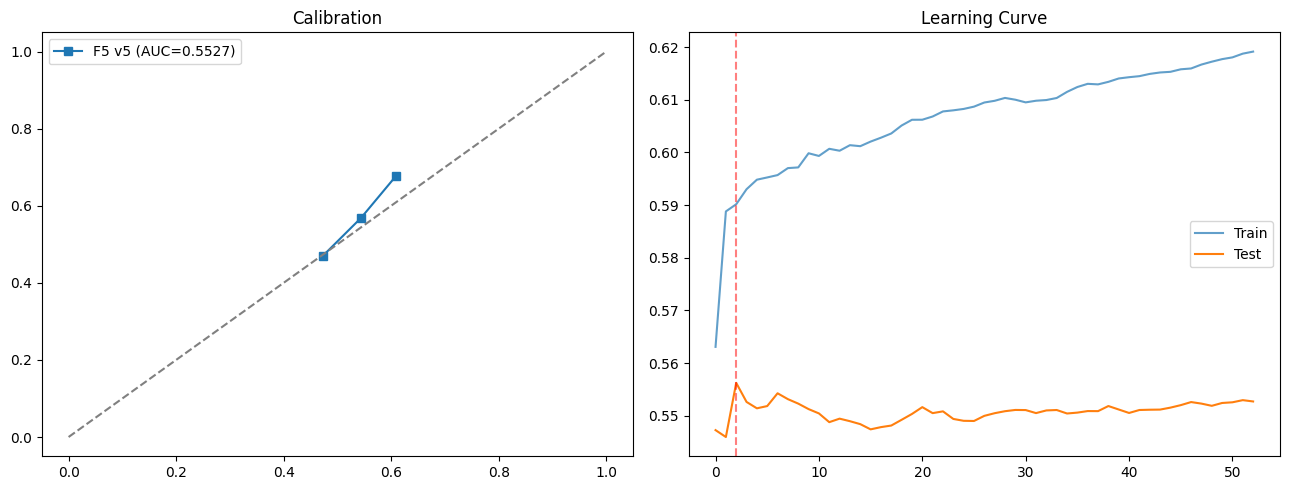


  ✅ Model saved: C:\Users\lmayn\Downloads\F5_Pro_System\models\xgb_f5_v5.json
  ✅ Feature means saved: C:\Users\lmayn\Downloads\F5_Pro_System\models\feature_means_f5_v5.json
  ⚠️  Missing from feature df: ['wind_speed_mph', 'temperature_f', 'implied_home_win_pct']
  Train [np.int32(2021), np.int32(2022)] → Test 2023: AUC=0.5616 (n=2,064)
  ⚠️  Missing from feature df: ['wind_speed_mph', 'temperature_f', 'implied_home_win_pct']
  Train [np.int32(2022), np.int32(2023)] → Test 2024: AUC=0.5756 (n=1,846)
  ⚠️  Missing from feature df: ['wind_speed_mph', 'temperature_f', 'implied_home_win_pct']
  Train [np.int32(2023), np.int32(2024)] → Test 2025: AUC=0.5630 (n=2,044)

  WF mean AUC: 0.5667 (95% CI [0.560, 0.574])
  Folds: [0.5616, 0.5756, 0.563]


In [60]:
statcast_rebuild_master_f5(cfg)  # ~1 min
rebuild_joins_only(cfg)          # ~2 min
build_nrfi_features(cfg)         # ~30s
run_feature_diagnostics()        # check new feature coverage
train_f5_model(cfg)              # saves feature_means automatically
walk_forward_validation()


In [61]:
run_rigor_assessment()
train_f5_model_full(cfg)

  ⚠️  Missing from feature df: ['wind_speed_mph', 'temperature_f', 'implied_home_win_pct']
╔═══════════════════════════════════════════════════════════════════╗
║  F5 PRO v5 — MATHEMATICAL RIGOR ASSESSMENT                       ║
║  2026-04-03 12:35                                                   ║
╠═══════════════════════════════════════════════════════════════════╣
║  DISCRIMINATION                                                    ║
║    OOS AUC:     0.5527  CI [0.528, 0.578]  [WEAK]        ║║
║    PR-AUC skill:+0.0437  test_n=2,014                            ║║
╠═══════════════════════════════════════════════════════════════════╣
║  CALIBRATION                                                       ║
║    Cal gap:     0.0171  [POOR]  mean_pred=0.5231  actual=0.5402  ║║
║    H-L p:       0.0552  [PASS]  (>0.05 = well calibrated)        ║║
╠═══════════════════════════════════════════════════════════════════╣
║  COMPLEXITY                                                        ║
║  